# Rent Growth Performance Drivers: Tract-Level Analysis (v4)

Analyze what drives **real** year-over-year rent growth at the census tract level using ACS 5-Year estimates,
LEHD LODES residence-based employment data, and national macro indicators across 5 CBSAs:
Boston, Dallas-Fort Worth, San Francisco, Denver, and Los Angeles.

### v4 Enhancements over v3
| Category | Improvement |
|----------|------------|
| **Spatial** | True queen-contiguity spatial weights from Census TIGER tract boundaries (replaces county-average proxy) |
| **Clustering** | K-means neighborhood archetypes — tracts grouped by demographic/economic profile |
| **Validation** | Expanding-window time-series cross-validation for temporal robustness |
| **Ensemble** | Stacked ensemble of LightGBM + XGBoost + CatBoost + RF with Ridge meta-learner |

By Jonathan Ling (2026)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests, warnings, os
from census import Census
from us import states
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error, silhouette_score
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from linearmodels.panel import PanelOLS
import geopandas as gpd
from libpysal.weights import Queen

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
print('All packages loaded (v4: + geopandas, libpysal, KMeans, StackingRegressor).')

All packages loaded (v4: + geopandas, libpysal, KMeans, StackingRegressor).


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
CENSUS_API_KEY = 'a3d6dadf1c20feb332824938e69fa48a827adff3'
c = Census(CENSUS_API_KEY)
YEARS = list(range(2015, 2024))

CBSA_COUNTIES = {
    'Boston': [('25', ['009', '017', '021', '023', '025']), ('33', ['015', '017'])],
    'Dallas-Fort Worth': [('48', ['085', '113', '121', '139', '231', '251', '257', '367', '397', '439'])],
    'San Francisco': [('06', ['001', '013', '041', '075', '081'])],
    'Denver': [('08', ['001', '005', '014', '019', '031', '035', '039', '047', '059', '093'])],
    'Los Angeles': [('06', ['037', '059'])],
}
STATE_ABBR = {'06': 'ca', '08': 'co', '25': 'ma', '33': 'nh', '48': 'tx'}
STATE_FIPS = sorted(set(sf for sc in CBSA_COUNTIES.values() for sf, _ in sc))

MORTGAGE_RATE = {2015: 3.85, 2016: 3.65, 2017: 3.99, 2018: 4.54,
                 2019: 3.94, 2020: 3.11, 2021: 2.96, 2022: 5.34, 2023: 6.81}
CPI_ANNUAL = {2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1, 2018: 251.1,
              2019: 255.7, 2020: 258.8, 2021: 270.9, 2022: 292.7, 2023: 304.7}
INFLATION_RATE = {yr: (CPI_ANNUAL[yr] - CPI_ANNUAL[yr-1]) / CPI_ANNUAL[yr-1] for yr in range(2015, 2024)}

MIN_RENTER_UNITS = 100
print(f'Config: {len(YEARS)} years, {len(CBSA_COUNTIES)} CBSAs, {len(STATE_FIPS)} states')

Config: 9 years, 5 CBSAs, 5 states


---\n## 1. Data Acquisition\n### 1a. ACS 5-Year Estimates

In [3]:
ACS_VARIABLES = {
    'B25064_001E': 'median_gross_rent', 'B19013_001E': 'median_hh_income',
    'B01003_001E': 'population', 'B01002_001E': 'median_age',
    'B25003_001E': 'occupied_units', 'B25003_002E': 'owner_occupied',
    'B25003_003E': 'renter_occupied', 'B25002_001E': 'total_housing_units',
    'B25002_003E': 'vacant_units', 'B25077_001E': 'median_home_value',
    'B23025_003E': 'labor_force', 'B23025_005E': 'unemployed',
    'B15003_001E': 'pop_25_plus', 'B15003_022E': 'bachelors',
    'B15003_023E': 'masters', 'B15003_024E': 'professional_degree',
    'B15003_025E': 'doctorate', 'B17001_001E': 'poverty_universe',
    'B17001_002E': 'below_poverty', 'B25070_001E': 'rent_burden_universe',
    'B25070_007E': 'rent_30_34pct', 'B25070_008E': 'rent_35_39pct',
    'B25070_009E': 'rent_40_49pct', 'B25070_010E': 'rent_50plus_pct',
    'B08301_001E': 'commute_universe', 'B08301_010E': 'public_transit_commuters',
    'B08303_001E': 'travel_time_universe', 'B08303_013E': 'commute_60_89min',
}
acs_fields = tuple(['NAME'] + list(ACS_VARIABLES.keys()))
print(f'Pulling {len(ACS_VARIABLES)} ACS variables per tract')

Pulling 28 ACS variables per tract


In [4]:
all_acs = []
for year in YEARS:
    for cbsa_name, state_counties in CBSA_COUNTIES.items():
        for state_fips, county_list in state_counties:
            for county_fips in county_list:
                try:
                    data = c.acs5.state_county_tract(acs_fields, state_fips, county_fips, Census.ALL, year=year)
                    for row in data:
                        row['year'] = year
                        row['cbsa'] = cbsa_name
                        row['GEOID'] = f"{row['state']}{row['county']}{row['tract']}"
                    all_acs.extend(data)
                except Exception as e:
                    print(f'  Warning: {cbsa_name} {state_fips}/{county_fips} {year}: {e}')
    print(f'  Completed ACS {year}')

df_acs = pd.DataFrame(all_acs).rename(columns=ACS_VARIABLES)
for col in ACS_VARIABLES.values():
    df_acs[col] = pd.to_numeric(df_acs[col], errors='coerce')
print(f'\nACS shape: {df_acs.shape}')
print(df_acs.groupby(["cbsa","year"])["GEOID"].nunique().unstack().mean(axis=1).astype(int))

  Completed ACS 2015


  Completed ACS 2016


  Completed ACS 2017


  Completed ACS 2018


  Completed ACS 2019


  Completed ACS 2020


  Completed ACS 2021


  Completed ACS 2022


  Completed ACS 2023

ACS shape: (65162, 35)
cbsa
Boston               1063
Dallas-Fort Worth    1473
Denver                659
Los Angeles          3010
San Francisco        1034
dtype: int64


### 1b. LODES Residence Area Characteristics (RAC)

In [5]:
LODES_COLS = {
    'C000': 'resident_workers', 'CE01': 'res_low_wage', 'CE02': 'res_mid_wage',
    'CE03': 'res_high_wage', 'CA01': 'res_age_29_or_less', 'CA02': 'res_age_30_54',
    'CA03': 'res_age_55_plus', 'CD01': 'res_edu_less_hs', 'CD02': 'res_edu_hs',
    'CD03': 'res_edu_some_college', 'CD04': 'res_edu_bachelors_plus',
    'CNS07': 'res_retail', 'CNS09': 'res_information', 'CNS10': 'res_finance',
    'CNS11': 'res_real_estate', 'CNS12': 'res_professional', 'CNS15': 'res_education',
    'CNS16': 'res_healthcare', 'CNS17': 'res_arts_entertainment', 'CNS18': 'res_accommodation_food',
}

def download_lodes_rac(state_abbr, year):
    url = f'https://lehd.ces.census.gov/data/lodes/LODES8/{state_abbr}/rac/{state_abbr}_rac_S000_JT00_{year}.csv.gz'
    try:
        df = pd.read_csv(url, compression='gzip', dtype={'h_geocode': str})
        df['GEOID'] = df['h_geocode'].str[:11]
        keep = ['GEOID'] + [c for c in LODES_COLS if c in df.columns]
        out = df[keep].groupby('GEOID').sum().reset_index().rename(columns=LODES_COLS)
        out['year'] = year
        return out
    except Exception as e:
        print(f'  Warning: RAC {state_abbr} {year}: {e}')
        return pd.DataFrame()

print(f'{len(LODES_COLS)} LODES RAC variables')

20 LODES RAC variables


In [6]:
unique_states = set()
for sc in CBSA_COUNTIES.values():
    for sf, _ in sc:
        unique_states.add(sf)

all_lodes = []
for sf in sorted(unique_states):
    abbr = STATE_ABBR[sf]
    for year in YEARS:
        dl = download_lodes_rac(abbr, year)
        if not dl.empty:
            all_lodes.append(dl)
    print(f'  Completed RAC {abbr.upper()}')

df_lodes = pd.concat(all_lodes, ignore_index=True)
print(f'\nLODES RAC shape: {df_lodes.shape}')

  Completed RAC CA


  Completed RAC CO


  Completed RAC MA


  Completed RAC NH


  Completed RAC TX

LODES RAC shape: (174529, 22)


### 1c. Census TIGER Tract Boundaries (v4)
Download tract boundary shapefiles to build a **queen contiguity** spatial weights matrix.
Two tracts are neighbors if they share an edge or vertex.

In [7]:
# Download TIGER/Line tract boundaries for each state
print('Downloading tract shapefiles from Census TIGER...')
gdfs = []
for sf in STATE_FIPS:
    url = f'https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_{sf}_tract.zip'
    try:
        gdf = gpd.read_file(url)
        gdfs.append(gdf[['GEOID', 'geometry']])
        print(f'  State {sf}: {len(gdf):,} tracts')
    except Exception as e:
        print(f'  Warning: Failed to download {sf}: {e}')

tracts_geo = pd.concat(gdfs, ignore_index=True)
print(f'\nTotal tract boundaries: {len(tracts_geo):,}')

  State 06: 9,129 tracts


  State 08: 1,447 tracts


  State 25: 1,620 tracts


  State 33: 350 tracts


  State 48: 6,896 tracts

Total tract boundaries: 19,442


---\n## 2. Data Processing & Feature Engineering

In [8]:
# Merge ACS + LODES
df = pd.merge(df_acs, df_lodes, on=['GEOID', 'year'], how='left')
print(f'Merged: {df.shape}  |  LODES coverage: {df["resident_workers"].notna().sum()}/{len(df)}')

# Density filter
pre = df['GEOID'].nunique()
df = df[df['renter_occupied'] >= MIN_RENTER_UNITS]
post = df['GEOID'].nunique()
print(f'Density filter (renter >= {MIN_RENTER_UNITS}): {pre:,} -> {post:,} tracts ({post/pre*100:.0f}%)')
print(df.groupby('cbsa')['GEOID'].nunique())

Merged: (65162, 55)  |  LODES coverage: 59904/65162
Density filter (renter >= 100): 8,773 -> 8,414 tracts (96%)
cbsa
Boston               1200
Dallas-Fort Worth    1955
Denver                724
Los Angeles          3345
San Francisco        1190
Name: GEOID, dtype: int64


In [9]:
# ── ACS derived rates ──
df['vacancy_rate'] = df['vacant_units'] / df['total_housing_units']
df['pct_renter'] = df['renter_occupied'] / df['occupied_units']
df['unemployment_rate'] = df['unemployed'] / df['labor_force']
df['pct_college'] = (df['bachelors'] + df['masters'] + df['professional_degree'] + df['doctorate']) / df['pop_25_plus']
df['poverty_rate'] = df['below_poverty'] / df['poverty_universe']
df['rent_burden_rate'] = (df['rent_30_34pct'] + df['rent_35_39pct'] + df['rent_40_49pct'] + df['rent_50plus_pct']) / df['rent_burden_universe']
df['rent_to_income'] = (df['median_gross_rent'] * 12) / df['median_hh_income']
df['pct_public_transit'] = df['public_transit_commuters'] / df['commute_universe']
df['pct_long_commute'] = df['commute_60_89min'] / df['travel_time_universe']

# ── LODES derived rates ──
df['pct_res_high_wage'] = df['res_high_wage'] / df['resident_workers']
df['pct_res_professional'] = df['res_professional'] / df['resident_workers']
df['pct_res_young_workers'] = df['res_age_29_or_less'] / df['resident_workers']
df['pct_res_bachelors_plus'] = df['res_edu_bachelors_plus'] / df['resident_workers']
df['worker_density'] = df['resident_workers'] / df['total_housing_units']
df['labor_participation'] = df['resident_workers'] / df['population']
df['pct_res_finance'] = df['res_finance'] / df['resident_workers']
df['pct_res_healthcare'] = df['res_healthcare'] / df['resident_workers']
df['pct_res_accommodation'] = df['res_accommodation_food'] / df['resident_workers']

# ── Macro ──
df['mortgage_rate'] = df['year'].map(MORTGAGE_RATE)
df['inflation_rate'] = df['year'].map(INFLATION_RATE)
df['mortgage_rate_chg'] = df['year'].map({yr: MORTGAGE_RATE[yr]-MORTGAGE_RATE[yr-1] for yr in range(2016,2024)})

print(f'Base features computed. Columns: {df.shape[1]}')

Base features computed. Columns: 76


In [10]:
# ── Dependent variable: real rent growth ──
df = df.sort_values(['GEOID', 'year'])
df['nominal_rent_growth'] = df.groupby('GEOID')['median_gross_rent'].pct_change()
df['rent_growth'] = (1 + df['nominal_rent_growth']) / (1 + df['inflation_rate']) - 1

# ── Growth features ──
df['income_growth'] = df.groupby('GEOID')['median_hh_income'].pct_change()
df['population_growth'] = df.groupby('GEOID')['population'].pct_change()
df['worker_growth'] = df.groupby('GEOID')['resident_workers'].pct_change()
df['home_value_growth'] = df.groupby('GEOID')['median_home_value'].pct_change()
df['housing_unit_growth'] = df.groupby('GEOID')['total_housing_units'].pct_change()

print(f'Rent growth computed. Median nominal: {df["nominal_rent_growth"].median():.4f}, real: {df["rent_growth"].median():.4f}')

Rent growth computed. Median nominal: 0.0489, real: 0.0176


### v4 Features: True Spatial Weights & Neighborhood Archetypes

In [11]:
# ── LAGGED FEATURES ──
df['lagged_rent_growth'] = df.groupby('GEOID')['rent_growth'].shift(1)
df['lagged_income_growth'] = df.groupby('GEOID')['income_growth'].shift(1)
df['lagged_home_value_growth'] = df.groupby('GEOID')['home_value_growth'].shift(1)
df['rent_growth_momentum'] = df.groupby('GEOID')['rent_growth'].transform(
    lambda x: x.shift(1).rolling(2, min_periods=1).mean()
)
print(f'Lagged features: {df["lagged_rent_growth"].notna().sum():,} / {len(df):,} obs')

Lagged features: 43,988 / 60,782 obs


In [12]:
# ── TRUE SPATIAL LAG via Queen Contiguity (v4) ──
# Build spatial weights from tract boundaries
our_geoids = set(df['GEOID'].unique())
tracts_filtered = tracts_geo[tracts_geo['GEOID'].isin(our_geoids)].copy().reset_index(drop=True)
print(f'Building queen contiguity for {len(tracts_filtered):,} tracts...')
W = Queen.from_dataframe(tracts_filtered, idVariable='GEOID', silence_warnings=True)
print(f'  Mean neighbors: {W.mean_neighbors:.1f}, Min: {W.min_neighbors}, Max: {W.max_neighbors}')
print(f'  Islands (no neighbors): {len(W.islands)}')

# Compute spatially-weighted average rent growth for each tract-year
spatial_records = []
for year in sorted(df['year'].unique()):
    yr_rg = df.loc[df['year'] == year, ['GEOID', 'rent_growth']].dropna().set_index('GEOID')['rent_growth']
    rg_dict = yr_rg.to_dict()
    for geoid in yr_rg.index:
        if geoid in W.neighbors and W.neighbors[geoid]:
            nbr_vals = [rg_dict[n] for n in W.neighbors[geoid] if n in rg_dict]
            sl = np.mean(nbr_vals) if nbr_vals else np.nan
        else:
            sl = np.nan
        spatial_records.append({'GEOID': geoid, 'year': year, 'spatial_lag_queen': sl})

df_spatial = pd.DataFrame(spatial_records)
df = df.merge(df_spatial, on=['GEOID', 'year'], how='left')

# Also keep county-level proxy for comparison
df['county_fips'] = df['GEOID'].str[:5]
county_agg = df.groupby(['county_fips', 'year']).agg(
    _rg_sum=('rent_growth', 'sum'), _rg_count=('rent_growth', 'count')
).reset_index()
df = df.merge(county_agg, on=['county_fips', 'year'], how='left')
df['spatial_lag_county'] = (df['_rg_sum'] - df['rent_growth']) / (df['_rg_count'] - 1)
df.drop(columns=['_rg_sum', '_rg_count'], inplace=True)
df['cbsa_avg_rg'] = df.groupby(['cbsa', 'year'])['rent_growth'].transform('mean')

queen_corr = df['spatial_lag_queen'].corr(df['rent_growth'])
county_corr = df['spatial_lag_county'].corr(df['rent_growth'])
print(f'\nSpatial lag correlations with rent growth:')
print(f'  Queen contiguity: {queen_corr:.3f}')
print(f'  County average:   {county_corr:.3f}')
print(f'  Queen is {"better" if abs(queen_corr) > abs(county_corr) else "similar"}')

Building queen contiguity for 7,422 tracts...


  Mean neighbors: 6.1, Min: 0, Max: 26
  Islands (no neighbors): 1



Spatial lag correlations with rent growth:
  Queen contiguity: 0.010
  County average:   0.029
  Queen is similar


In [13]:
# ── RELATIVE-TO-CBSA FEATURES ──
cbsa_medians = df.groupby(['cbsa', 'year']).agg(
    _med_income=('median_hh_income', 'median'),
    _med_rent=('median_gross_rent', 'median'),
    _med_hv=('median_home_value', 'median'),
).reset_index()
df = df.merge(cbsa_medians, on=['cbsa', 'year'], how='left')
df['income_vs_cbsa'] = df['median_hh_income'] / df['_med_income']
df['rent_vs_cbsa'] = df['median_gross_rent'] / df['_med_rent']
df['home_value_vs_cbsa'] = df['median_home_value'] / df['_med_hv']
df.drop(columns=['_med_income', '_med_rent', '_med_hv'], inplace=True)
print('Relative-to-CBSA features computed.')

Relative-to-CBSA features computed.


In [14]:
# ── INTERACTION TERMS ──
df['pop_growth_x_vacancy'] = df['population_growth'] * df['vacancy_rate']
df['income_growth_x_pct_renter'] = df['income_growth'] * df['pct_renter']
df['supply_demand_ratio'] = df['housing_unit_growth'] / (df['population_growth'].clip(lower=0.001))

# ── COVID & CBSA dummies ──
df['covid_2020'] = (df['year'] == 2020).astype(int)
df['covid_2021'] = (df['year'] == 2021).astype(int)
cbsa_dum = pd.get_dummies(df['cbsa'], prefix='cbsa', drop_first=False, dtype=int)
df = pd.concat([df, cbsa_dum.drop(columns='cbsa_Los Angeles')], axis=1)
print(f'Interactions and dummies computed. Columns: {df.shape[1]}')

Interactions and dummies computed. Columns: 103


### Neighborhood Archetypes via K-Means (v4)
Cluster tracts by their average demographic/economic profile to identify **neighborhood archetypes**.
Clusters capture combinations of features that commonly co-occur (e.g., "affluent suburban", "dense urban core",
"working-class transit-oriented") — each archetype may have different rent growth dynamics.

In [15]:
# K-Means clustering on tract-level average profiles
CLUSTER_FEATURES = [
    'median_hh_income', 'median_age', 'median_home_value',
    'pct_renter', 'pct_college', 'poverty_rate', 'vacancy_rate',
    'rent_to_income', 'pct_public_transit', 'worker_density',
    'pct_res_high_wage', 'pct_res_professional', 'unemployment_rate',
]

# Average each tract across years for a stable profile
tract_profiles = df.groupby('GEOID')[CLUSTER_FEATURES].mean().dropna()
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(tract_profiles)
print(f'Clustering {len(tract_profiles):,} tracts on {len(CLUSTER_FEATURES)} profile features')

# Find optimal k via silhouette score
sil_scores = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_km)
    sil = silhouette_score(X_km, labels)
    sil_scores[k] = sil
    print(f'  k={k}: silhouette={sil:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k={best_k} (silhouette={sil_scores[best_k]:.4f})')

# Fit final model
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
tract_profiles['cluster'] = km_final.fit_predict(X_km)

# Merge cluster labels into main df
df = df.merge(tract_profiles[['cluster']].reset_index(), on='GEOID', how='left')
# Fill unclustered tracts with most common cluster
df['cluster'] = df['cluster'].fillna(df['cluster'].mode().iloc[0]).astype(int)

# Create cluster dummies (drop last as reference)
cluster_dum = pd.get_dummies(df['cluster'], prefix='cluster', dtype=int)
ref_cluster = cluster_dum.columns[-1]
cluster_dum = cluster_dum.drop(columns=ref_cluster)
df = pd.concat([df, cluster_dum], axis=1)
CLUSTER_COLS = list(cluster_dum.columns)
print(f'Cluster dummies: {CLUSTER_COLS} (ref={ref_cluster})')

Clustering 7,422 tracts on 13 profile features


  k=3: silhouette=0.1914


  k=4: silhouette=0.2022


  k=5: silhouette=0.2073


  k=6: silhouette=0.1776


  k=7: silhouette=0.1832


  k=8: silhouette=0.1892

Best k=5 (silhouette=0.2073)
Cluster dummies: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3'] (ref=cluster_4)


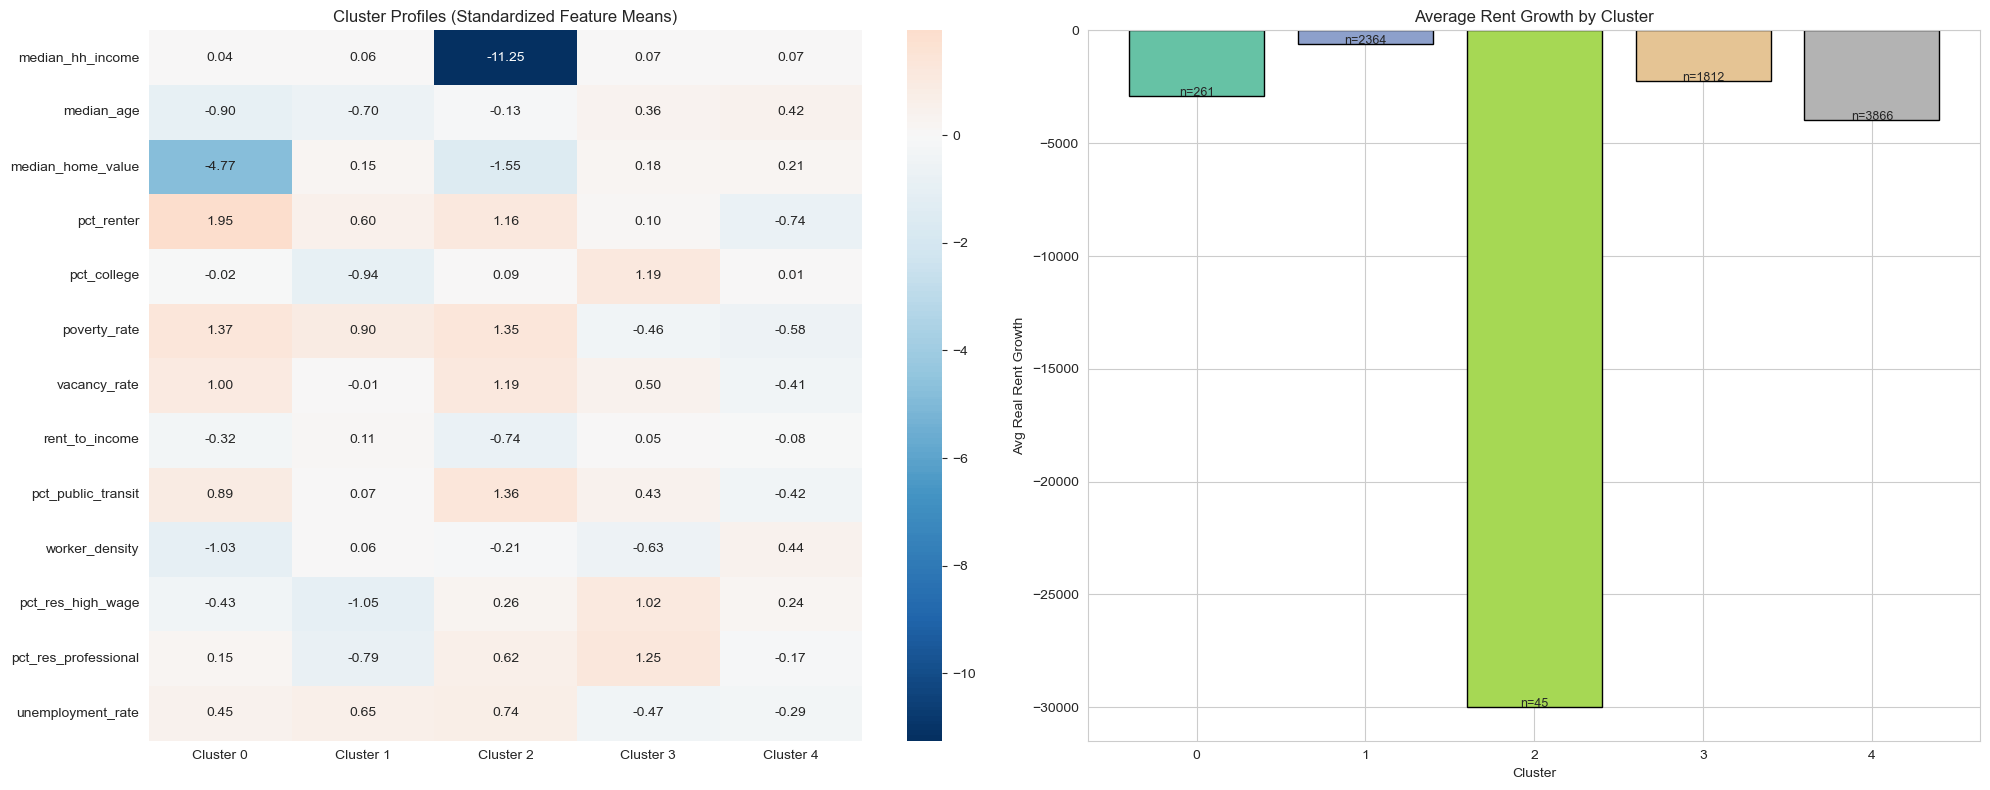


Cluster Centers (original scale):
           median_hh_income  median_age  median_home_value  pct_renter  pct_college  poverty_rate  vacancy_rate  rent_to_income  pct_public_transit  worker_density  pct_res_high_wage  pct_res_professional  unemployment_rate
Cluster 0         -597148.6        32.0       -561321773.6         1.0          0.4           0.3           0.1         -3550.2                 0.1             1.0                0.5                   0.1                0.1
Cluster 1         -103201.4        33.3         -7122331.7         0.6          0.2           0.2           0.1          -155.3                 0.1             1.3                0.4                   0.1                0.1
Cluster 2      -236581907.1        37.1       -198213824.8         0.8          0.4           0.3           0.1         -6776.2                 0.2             1.2                0.6                   0.1                0.1
Cluster 3           80331.6        40.4         -3210301.3         0.

In [16]:
# Visualize cluster profiles
centers = pd.DataFrame(scaler_km.inverse_transform(km_final.cluster_centers_),
                        columns=CLUSTER_FEATURES)
centers.index = [f'Cluster {i}' for i in range(best_k)]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap of standardized cluster centers
centers_std = pd.DataFrame(km_final.cluster_centers_, columns=CLUSTER_FEATURES,
                            index=[f'Cluster {i}' for i in range(best_k)])
sns.heatmap(centers_std.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Cluster Profiles (Standardized Feature Means)')

# Cluster sizes and avg rent growth
cluster_stats = df[df['rent_growth'].notna()].groupby('cluster').agg(
    n_tracts=('GEOID', 'nunique'),
    avg_rent_growth=('rent_growth', 'mean'),
    med_income=('median_hh_income', 'median'),
).reset_index()
bars = axes[1].bar(cluster_stats['cluster'].astype(str), cluster_stats['avg_rent_growth'],
                    color=plt.cm.Set2(np.linspace(0, 1, best_k)), edgecolor='black')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Avg Real Rent Growth')
axes[1].set_title('Average Rent Growth by Cluster')
axes[1].axhline(y=0, color='black', lw=0.5, ls='--')
for bar, (_, row) in zip(bars, cluster_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f'n={int(row["n_tracts"])}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print('\nCluster Centers (original scale):')
print(centers.round(1).to_string())

In [17]:
# ── Prepare modeling data ──
df_model = df[df['year'] >= 2017].copy().replace([np.inf, -np.inf], np.nan)
q_lo, q_hi = df_model['rent_growth'].quantile(0.01), df_model['rent_growth'].quantile(0.99)
df_model = df_model[(df_model['rent_growth'] >= q_lo) & (df_model['rent_growth'] <= q_hi)]

FEATURE_COLS = [
    # ACS levels
    'median_hh_income', 'population', 'median_age', 'median_home_value',
    'vacancy_rate', 'pct_renter', 'unemployment_rate', 'pct_college',
    'poverty_rate', 'rent_burden_rate', 'rent_to_income',
    'pct_public_transit', 'pct_long_commute',
    # LODES rates
    'pct_res_high_wage', 'pct_res_professional', 'pct_res_young_workers',
    'pct_res_bachelors_plus', 'worker_density', 'labor_participation',
    'pct_res_finance', 'pct_res_healthcare', 'pct_res_accommodation',
    # Growth
    'income_growth', 'population_growth', 'worker_growth',
    'home_value_growth', 'housing_unit_growth',
    # Macro
    'mortgage_rate', 'mortgage_rate_chg', 'inflation_rate',
    # Lagged
    'lagged_rent_growth', 'lagged_income_growth', 'lagged_home_value_growth',
    'rent_growth_momentum',
    # v4: True spatial lag
    'spatial_lag_queen', 'spatial_lag_county',
    # Relative
    'income_vs_cbsa', 'rent_vs_cbsa', 'home_value_vs_cbsa',
    # Interactions
    'pop_growth_x_vacancy', 'income_growth_x_pct_renter', 'supply_demand_ratio',
    # Controls
    'covid_2020', 'covid_2021',
    'cbsa_Boston', 'cbsa_Dallas-Fort Worth', 'cbsa_Denver', 'cbsa_San Francisco',
] + CLUSTER_COLS  # v4: cluster dummies

TARGET = 'rent_growth'
keep_cols = FEATURE_COLS + [TARGET, 'cbsa', 'year', 'GEOID', 'nominal_rent_growth', 'county_fips', 'cbsa_avg_rg', 'cluster']
df_clean = df_model[[c for c in keep_cols if c in df_model.columns]].dropna(subset=FEATURE_COLS + [TARGET])

print(f'Model-ready data: {df_clean.shape}')
print(f'Features: {len(FEATURE_COLS)} (incl. {len(CLUSTER_COLS)} cluster dummies)')
print(f'Years: {sorted(df_clean["year"].unique())}')
print(df_clean['cbsa'].value_counts())

Model-ready data: (40171, 60)
Features: 52 (incl. 4 cluster dummies)
Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
cbsa
Los Angeles          17865
Dallas-Fort Worth     7107
San Francisco         6049
Boston                5736
Denver                3414
Name: count, dtype: int64


---\n## 3. Exploratory Data Analysis

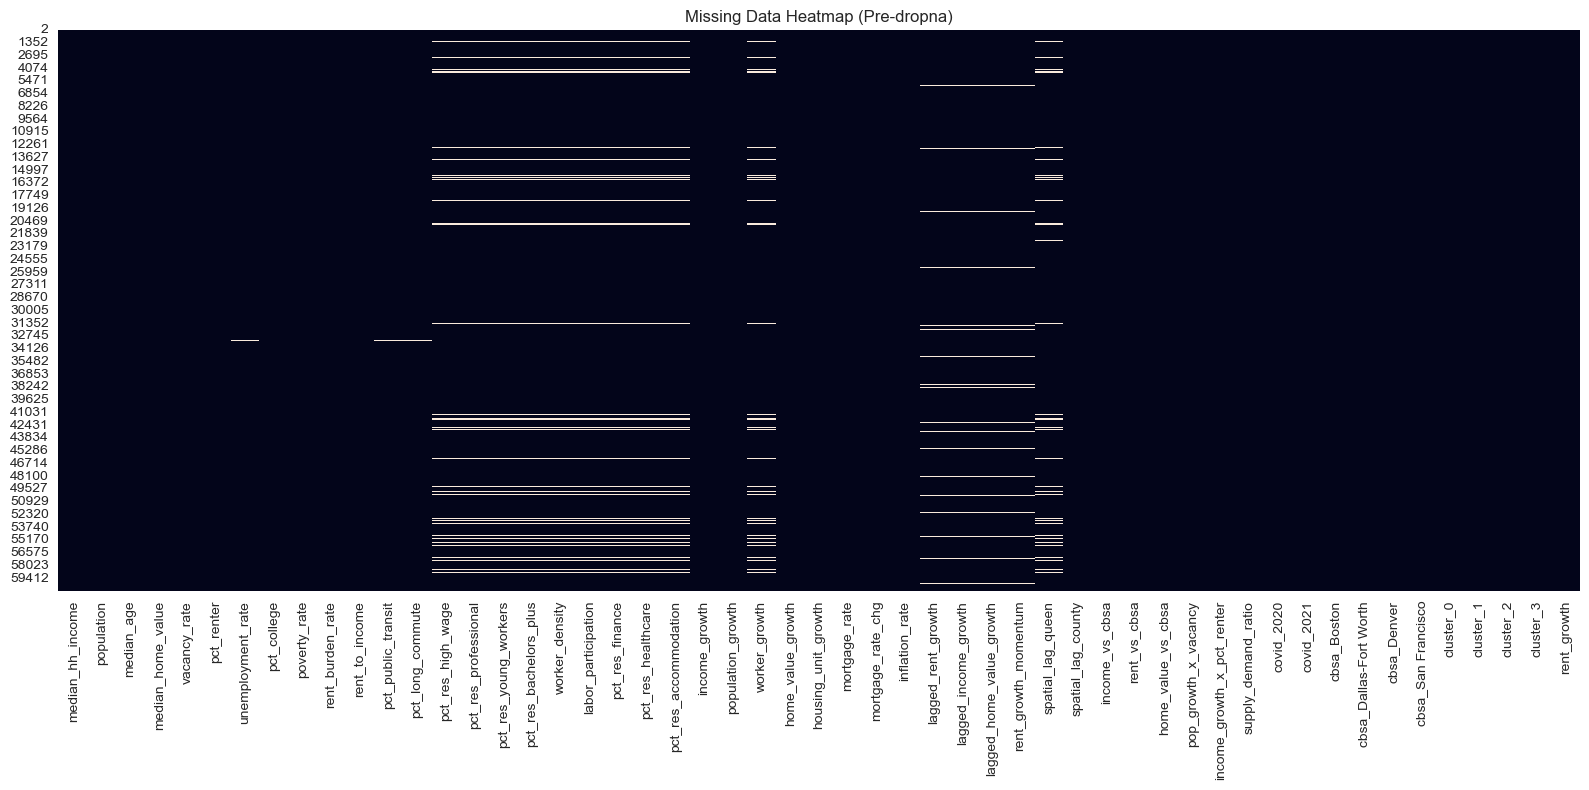

In [18]:
# Missing data heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(df_model[FEATURE_COLS + [TARGET]].isnull(), cbar=False, ax=ax)
ax.set_title('Missing Data Heatmap (Pre-dropna)')
plt.tight_layout(); plt.show()

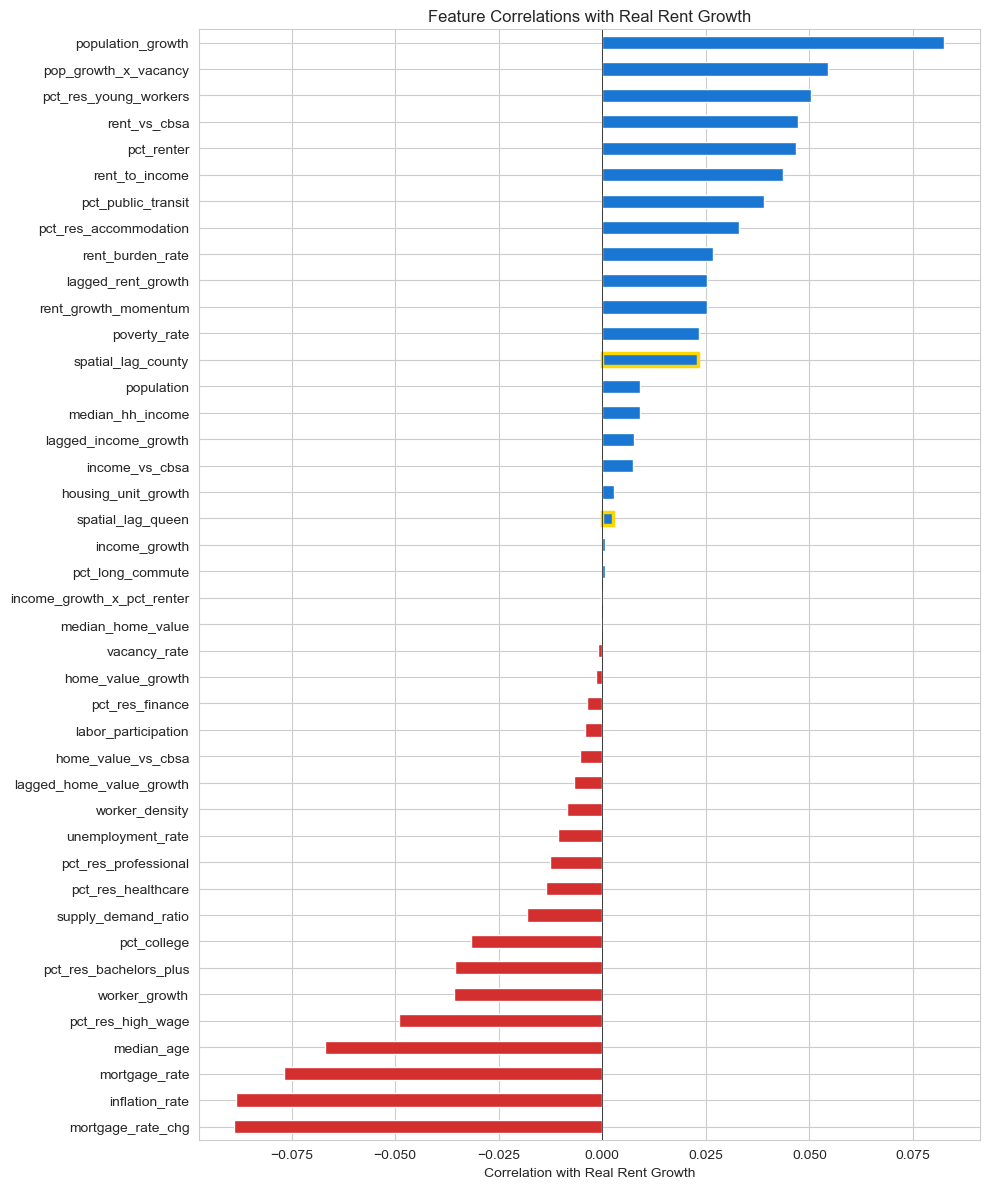

Top 5 positive: {'pct_renter': 0.047, 'rent_vs_cbsa': 0.047, 'pct_res_young_workers': 0.05, 'pop_growth_x_vacancy': 0.054, 'population_growth': 0.083}
Top 5 negative: {'mortgage_rate_chg': -0.089, 'inflation_rate': -0.088, 'mortgage_rate': -0.077, 'median_age': -0.067, 'pct_res_high_wage': -0.049}


In [19]:
# Correlation with rent growth
cont = [f for f in FEATURE_COLS if not f.startswith('cbsa_') and not f.startswith('covid_') and not f.startswith('cluster')]
corr_t = df_clean[cont + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#d32f2f' if v < 0 else '#1976d2' for v in corr_t]
corr_t.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with Real Rent Growth')
ax.set_title('Feature Correlations with Real Rent Growth')
ax.axvline(x=0, color='black', lw=0.5)
v4_feats = {'spatial_lag_queen','spatial_lag_county'}
for i, label in enumerate(corr_t.index):
    if label in v4_feats:
        ax.get_children()[i].set_edgecolor('gold')
        ax.get_children()[i].set_linewidth(2.5)
plt.tight_layout(); plt.show()
print(f'Top 5 positive: {corr_t.tail(5).round(3).to_dict()}')
print(f'Top 5 negative: {corr_t.head(5).round(3).to_dict()}')

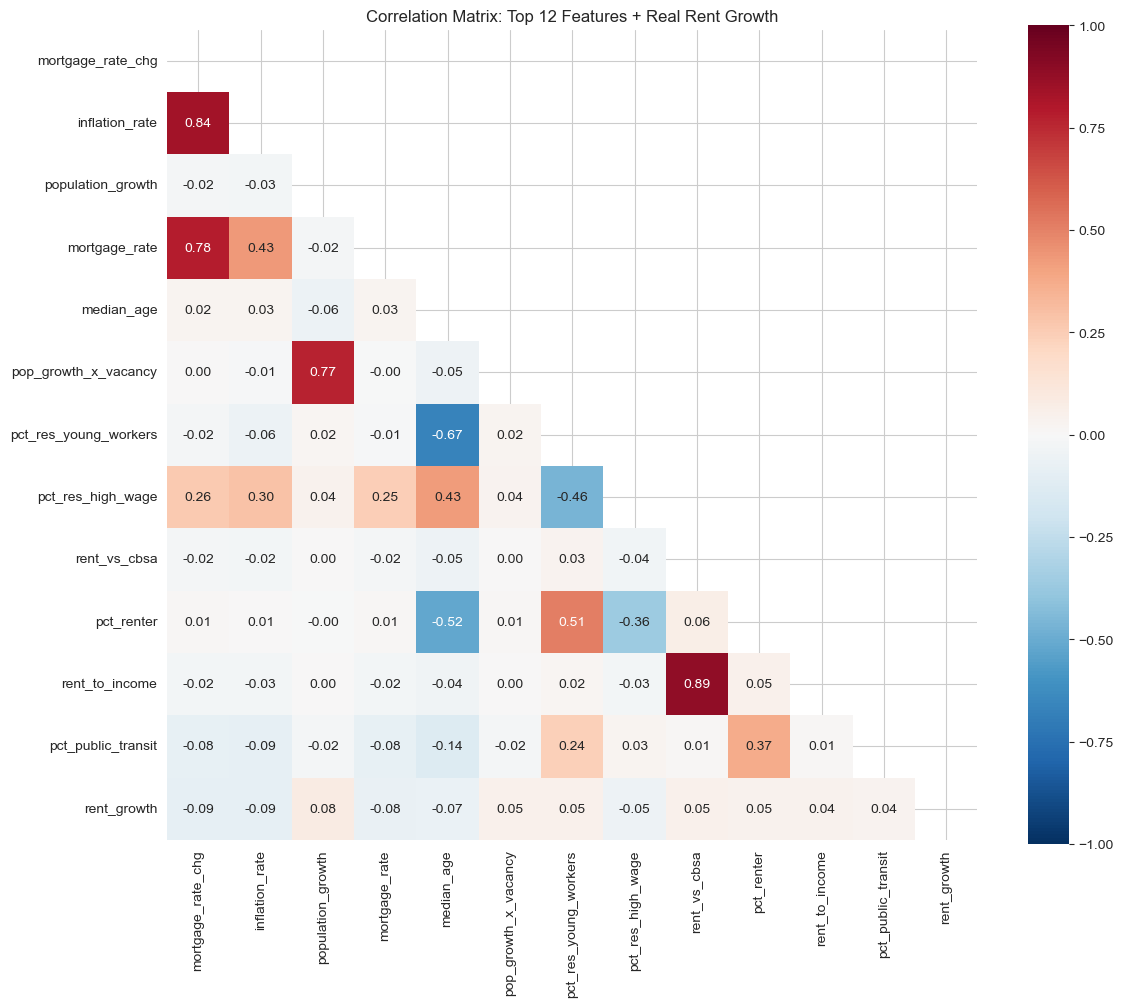

In [20]:
# Correlation matrix - top features
top_f = corr_t.abs().nlargest(12).index.tolist()
cm = df_clean[top_f + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, mask=np.triu(np.ones_like(cm, dtype=bool)), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation Matrix: Top 12 Features + Real Rent Growth')
plt.tight_layout(); plt.show()

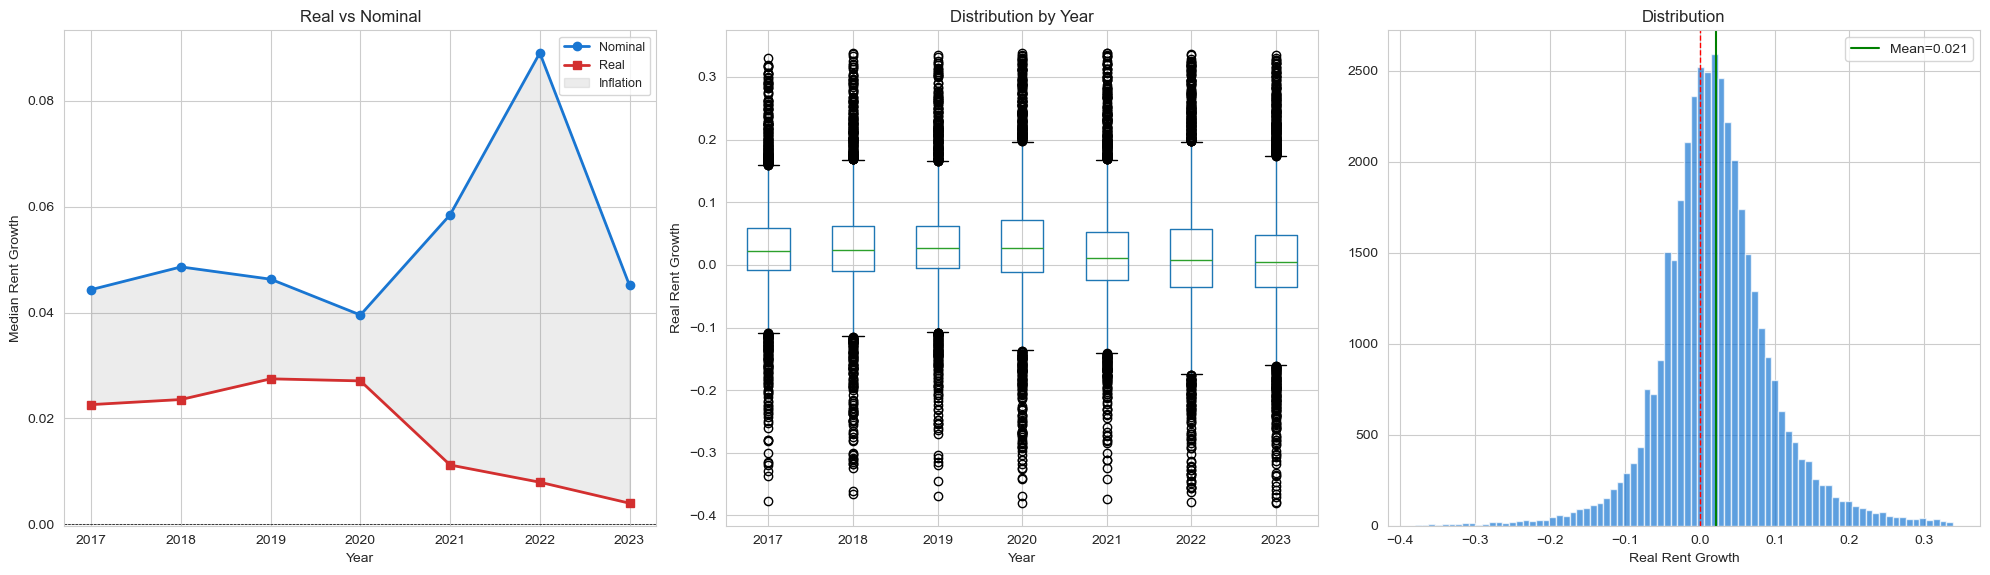

In [21]:
# Rent growth over time
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ys = df_clean.groupby('year').agg(real=(TARGET,'median'), nom=('nominal_rent_growth','median')).reset_index()
axes[0].plot(ys['year'], ys['nom'], 'o-', label='Nominal', lw=2, color='#1976d2')
axes[0].plot(ys['year'], ys['real'], 's-', label='Real', lw=2, color='#d32f2f')
axes[0].fill_between(ys['year'], ys['nom'], ys['real'], alpha=0.15, color='gray', label='Inflation')
axes[0].axhline(y=0, color='black', lw=0.5, ls='--')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Median Rent Growth')
axes[0].set_title('Real vs Nominal'); axes[0].legend(fontsize=9)
df_clean.boxplot(column=TARGET, by='year', ax=axes[1])
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Real Rent Growth')
axes[1].set_title('Distribution by Year'); plt.suptitle('')
axes[2].hist(df_clean[TARGET], bins=80, color='#1976d2', alpha=0.7, edgecolor='white')
axes[2].axvline(x=0, color='red', lw=1, ls='--')
axes[2].axvline(x=df_clean[TARGET].mean(), color='green', lw=1.5, label=f'Mean={df_clean[TARGET].mean():.3f}')
axes[2].set_xlabel('Real Rent Growth'); axes[2].set_title('Distribution'); axes[2].legend()
plt.tight_layout(); plt.show()

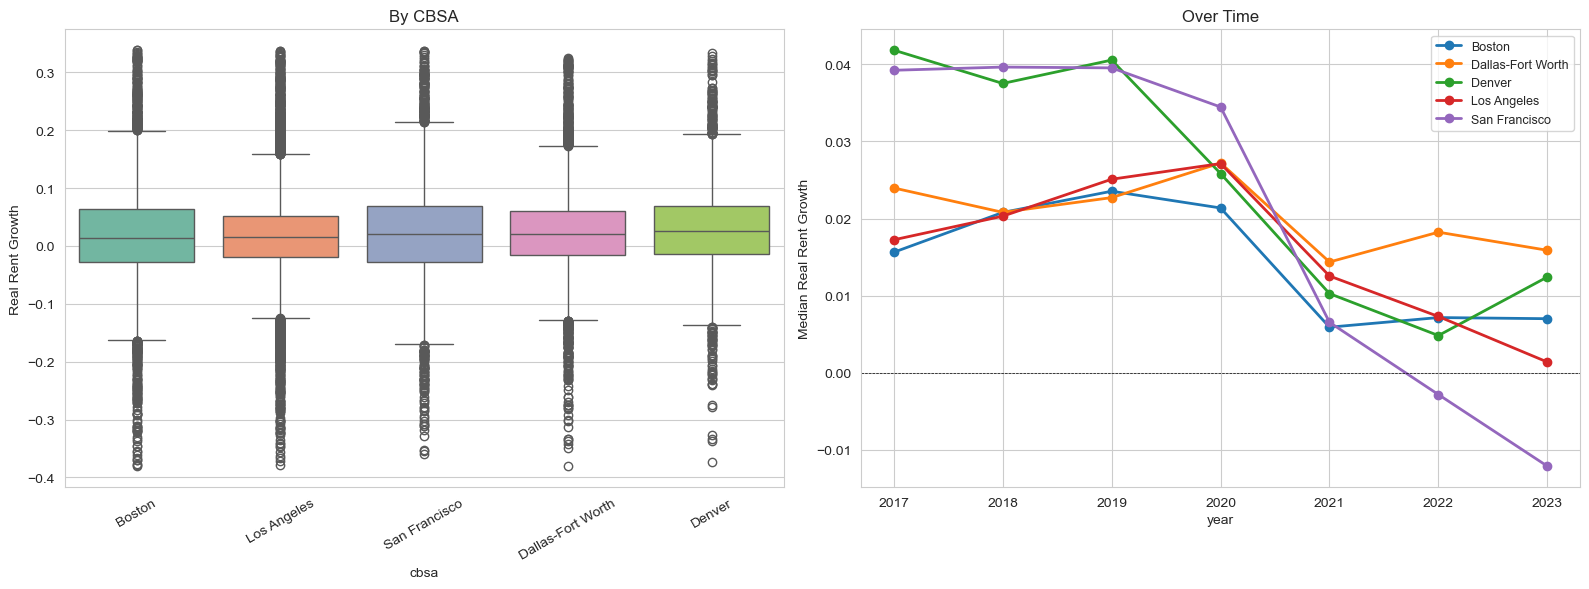

In [22]:
# CBSA comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
co = df_clean.groupby('cbsa')[TARGET].median().sort_values().index
sns.boxplot(data=df_clean, x='cbsa', y=TARGET, order=co, ax=axes[0], palette='Set2')
axes[0].set_ylabel('Real Rent Growth'); axes[0].set_title('By CBSA'); axes[0].tick_params(axis='x', rotation=30)
df_clean.groupby(['cbsa','year'])[TARGET].median().unstack(level=0).plot(ax=axes[1], marker='o', lw=2)
axes[1].set_ylabel('Median Real Rent Growth'); axes[1].set_title('Over Time')
axes[1].axhline(y=0, color='black', lw=0.5, ls='--'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

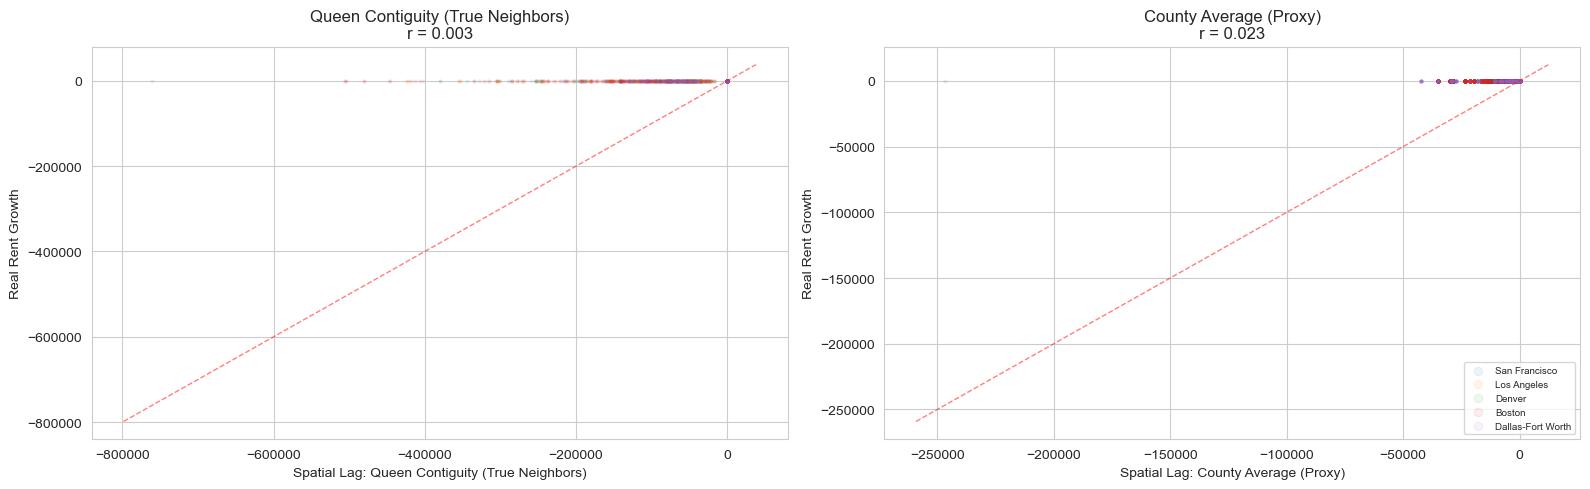

In [23]:
# Spatial lag comparison: queen vs county
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (feat, label) in zip(axes, [
    ('spatial_lag_queen', 'Queen Contiguity (True Neighbors)'),
    ('spatial_lag_county', 'County Average (Proxy)'),
]):
    for cbsa in df_clean['cbsa'].unique():
        mask = df_clean['cbsa'] == cbsa
        ax.scatter(df_clean.loc[mask, feat], df_clean.loc[mask, TARGET], alpha=0.08, s=4, label=cbsa)
    r = df_clean[feat].corr(df_clean[TARGET])
    ax.set_xlabel(f'Spatial Lag: {label}'); ax.set_ylabel('Real Rent Growth')
    ax.set_title(f'{label}\nr = {r:.3f}')
    ax.plot(ax.get_xlim(), ax.get_xlim(), 'r--', lw=1, alpha=0.5)
axes[1].legend(fontsize=7, markerscale=3)
plt.tight_layout(); plt.show()

---
## 4. Modeling

### Model Suite (v4)
| Model | Type | Purpose |
|-------|------|---------|
| OLS | Linear | Interpretable coefficients |
| Lasso | Linear + L1 | Feature selection |
| Random Forest | Ensemble | Non-linear baseline |
| XGBoost | Gradient Boosted | Strong tabular performer |
| LightGBM | Gradient Boosted | Often best on tabular |
| CatBoost | Gradient Boosted | Ordered boosting |
| **Stacked Ensemble** | **Meta-learner** | **Combines top models via Ridge** |
| Panel FE | Fixed Effects | Within-tract variation |
| Two-Stage | Decomposition | Macro vs local separation |

In [24]:
# Train/test split
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_clean.index, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)
print(f'Random split - Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}  Features: {X_train.shape[1]}')

Random split - Train: 32,136  Test: 8,035  Features: 52


In [25]:
# === OLS ===
X_tr_ols = sm.add_constant(X_tr_s, has_constant='add')
X_te_ols = sm.add_constant(X_te_s, has_constant='add')
ols_model = sm.OLS(y_train, X_tr_ols).fit()
y_ols_tr = ols_model.predict(X_tr_ols)
y_ols_te = ols_model.predict(X_te_ols)
ols_df = pd.DataFrame({'Feature': ['const']+FEATURE_COLS, 'Coef': ols_model.params,
    'P': ols_model.pvalues}).set_index('Feature')
print(f'=== OLS === Train R2: {ols_model.rsquared:.4f} | Test R2: {r2_score(y_test, y_ols_te):.4f}')
sig = ols_df[(ols_df['P']<0.05)&(ols_df.index!='const')].sort_values('Coef',key=abs,ascending=False)
print(f'Significant (p<0.05): {len(sig)}/{len(FEATURE_COLS)}')

=== OLS === Train R2: 0.0330 | Test R2: 0.0262
Significant (p<0.05): 23/52


In [26]:
# === Lasso ===
lasso_cv = LassoCV(alphas=np.logspace(-6, -1, 100), cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_tr_s, y_train)
y_las_tr = lasso_cv.predict(X_tr_s)
y_las_te = lasso_cv.predict(X_te_s)
lasso_coefs = pd.Series(lasso_cv.coef_, index=FEATURE_COLS)
print(f'=== Lasso === Alpha: {lasso_cv.alpha_:.6f} | Train: {r2_score(y_train,y_las_tr):.4f} | Test: {r2_score(y_test,y_las_te):.4f}')
print(f'Non-zero: {(lasso_coefs!=0).sum()}/{len(lasso_coefs)}')

=== Lasso === Alpha: 0.000210 | Train: 0.0320 | Test: 0.0267
Non-zero: 34/52


In [27]:
# === Random Forest ===
rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_rf_tr = rf_model.predict(X_train)
y_rf_te = rf_model.predict(X_test)
print(f'=== RF === Train: {r2_score(y_train,y_rf_tr):.4f} | Test: {r2_score(y_test,y_rf_te):.4f}')

=== RF === Train: 0.4036 | Test: 0.2077


In [28]:
# === XGBoost ===
xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_xgb_tr = xgb_model.predict(X_train)
y_xgb_te = xgb_model.predict(X_test)
print(f'=== XGB === Train: {r2_score(y_train,y_xgb_tr):.4f} | Test: {r2_score(y_test,y_xgb_te):.4f}')

=== XGB === Train: 0.6493 | Test: 0.2937


In [29]:
# === LightGBM ===
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, max_depth=8, learning_rate=0.03, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_samples=30, random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
y_lgb_tr = lgb_model.predict(X_train)
y_lgb_te = lgb_model.predict(X_test)
print(f'=== LightGBM === Train: {r2_score(y_train,y_lgb_tr):.4f} | Test: {r2_score(y_test,y_lgb_te):.4f}')
print(f'Best iteration: {lgb_model.best_iteration_}')

=== LightGBM === Train: 0.8091 | Test: 0.4781
Best iteration: 994


In [30]:
# === CatBoost ===
cat_model = CatBoostRegressor(
    iterations=1000, depth=8, learning_rate=0.03,
    l2_leaf_reg=3.0, subsample=0.8, random_seed=42,
    verbose=0, early_stopping_rounds=50
)
cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=0)
y_cat_tr = cat_model.predict(X_train)
y_cat_te = cat_model.predict(X_test)
print(f'=== CatBoost === Train: {r2_score(y_train,y_cat_tr):.4f} | Test: {r2_score(y_test,y_cat_te):.4f}')

=== CatBoost === Train: 0.4944 | Test: 0.2491


### Stacked Ensemble (v4)
Combines predictions from LightGBM, XGBoost, CatBoost, and Random Forest using a **Ridge regression meta-learner**.
Base models generate out-of-fold predictions via 5-fold CV to avoid leakage.

In [31]:
# === Stacked Ensemble ===
stack_model = StackingRegressor(
    estimators=[
        ('lgb', lgb.LGBMRegressor(n_estimators=500, max_depth=8, learning_rate=0.03,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
            random_state=42, n_jobs=-1, verbose=-1)),
        ('xgb', xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)),
        ('cat', CatBoostRegressor(iterations=500, depth=8, learning_rate=0.03,
            l2_leaf_reg=3.0, random_seed=42, verbose=0)),
        ('rf', RandomForestRegressor(n_estimators=300, max_depth=15,
            min_samples_leaf=20, random_state=42, n_jobs=-1)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1,
)
print('Fitting stacked ensemble (5-fold CV for base models)...')
stack_model.fit(X_train, y_train)
y_stack_tr = stack_model.predict(X_train)
y_stack_te = stack_model.predict(X_test)
print(f'=== Stacked Ensemble === Train: {r2_score(y_train,y_stack_tr):.4f} | Test: {r2_score(y_test,y_stack_te):.4f}')

# Show meta-learner weights
meta_coefs = pd.Series(stack_model.final_estimator_.coef_,
                         index=['LightGBM','XGBoost','CatBoost','RF'])
print(f'\nMeta-learner weights:')
print(meta_coefs.round(4).to_string())

Fitting stacked ensemble (5-fold CV for base models)...


=== Stacked Ensemble === Train: 0.7847 | Test: 0.4824

Meta-learner weights:
LightGBM    1.2910
XGBoost     0.4098
CatBoost   -0.5445
RF         -0.1360


### Panel Fixed Effects

In [32]:
# === Panel FE ===
panel_df = df_clean.set_index(['GEOID', 'year'])
panel_features = [f for f in FEATURE_COLS if not f.startswith('cbsa_') and not f.startswith('cluster')]
panel_mod = PanelOLS(panel_df[TARGET], panel_df[panel_features], entity_effects=True, drop_absorbed=True)
panel_res = panel_mod.fit(cov_type='clustered', cluster_entity=True)
print(f'=== Panel FE === Within R2: {panel_res.rsquared_within:.4f} | Overall R2: {panel_res.rsquared_overall:.4f}')
print(f'Entities: {panel_res.entity_info.total}')
panel_summary = pd.DataFrame({'Coef': panel_res.params, 'P': panel_res.pvalues})
panel_sig = panel_summary[panel_summary['P']<0.05].sort_values('Coef',key=abs,ascending=False)
print(f'\nTop significant:')
print(panel_sig.head(12).to_string())

=== Panel FE === Within R2: 0.0267 | Overall R2: -0.1559
Entities: 7242.0

Top significant:
                         Coef             P
inflation_rate      -0.242887  1.303801e-03
population_growth    0.152472  0.000000e+00
poverty_rate        -0.084783  6.626699e-12
housing_unit_growth -0.079946  1.159479e-04
pct_college          0.065477  1.125190e-06
pct_res_high_wage    0.061032  1.946273e-03
unemployment_rate   -0.054284  1.155507e-02
pct_public_transit   0.046655  1.032493e-02
rent_burden_rate     0.039853  1.505054e-10
worker_density       0.031405  1.869314e-04
covid_2021          -0.014685  2.568566e-09
mortgage_rate       -0.008002  6.750644e-11


### Two-Stage Decomposition

In [33]:
# === Two-Stage Model ===
df_train_2s = df_clean.loc[idx_train].copy()
df_test_2s = df_clean.loc[idx_test].copy()

cbsa_year_train = df_train_2s.groupby(['cbsa', 'year']).agg(
    cbsa_rg=(TARGET, 'mean'), mortgage_rate=('mortgage_rate', 'first'),
    inflation_rate=('inflation_rate', 'first'), mortgage_rate_chg=('mortgage_rate_chg', 'first'),
    covid_2020=('covid_2020', 'first'), covid_2021=('covid_2021', 'first'),
).reset_index()
cbsa_dum_s1 = pd.get_dummies(cbsa_year_train['cbsa'], prefix='cbsa', dtype=int).drop(columns='cbsa_Los Angeles')
stage1_X = pd.concat([cbsa_year_train[['mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021']], cbsa_dum_s1], axis=1)
stage1_model = sm.OLS(cbsa_year_train['cbsa_rg'], sm.add_constant(stage1_X)).fit()
print(f'Stage 1 R2: {stage1_model.rsquared:.4f} (n={len(cbsa_year_train)})')

cbsa_year_test = df_test_2s[['cbsa','year','mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021']].drop_duplicates()
cbsa_dum_s1_te = pd.get_dummies(cbsa_year_test['cbsa'], prefix='cbsa', dtype=int).drop(columns='cbsa_Los Angeles')
stage1_X_te = pd.concat([cbsa_year_test[['mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021']].reset_index(drop=True), cbsa_dum_s1_te.reset_index(drop=True)], axis=1)
cbsa_year_test = cbsa_year_test.reset_index(drop=True)
cbsa_year_test['stage1_pred'] = stage1_model.predict(sm.add_constant(stage1_X_te))

train_cbsa_means = df_train_2s.groupby(['cbsa','year'])[TARGET].transform('mean')
df_train_2s['deviation'] = df_train_2s[TARGET] - train_cbsa_means
local_features = [f for f in FEATURE_COLS if f not in ['mortgage_rate','inflation_rate','mortgage_rate_chg','covid_2020','covid_2021'] and not f.startswith('cbsa_')]
stage2_model = lgb.LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.03, verbose=-1, n_jobs=-1, random_state=42)
stage2_model.fit(df_train_2s[local_features].values, df_train_2s['deviation'].values)

df_test_2s = df_test_2s.merge(cbsa_year_test[['cbsa','year','stage1_pred']], on=['cbsa','year'], how='left')
df_test_2s['stage2_pred'] = stage2_model.predict(df_test_2s[local_features].values)
df_test_2s['combined_pred'] = df_test_2s['stage1_pred'] + df_test_2s['stage2_pred']
y_2s_te = df_test_2s['combined_pred'].values
y_2s_actual = df_test_2s[TARGET].values
print(f'=== Two-Stage === Test R2: {r2_score(y_2s_actual, y_2s_te):.4f}')

Stage 1 R2: 0.6452 (n=35)


=== Two-Stage === Test R2: 0.3254


---\n## 5. Results & Comparison

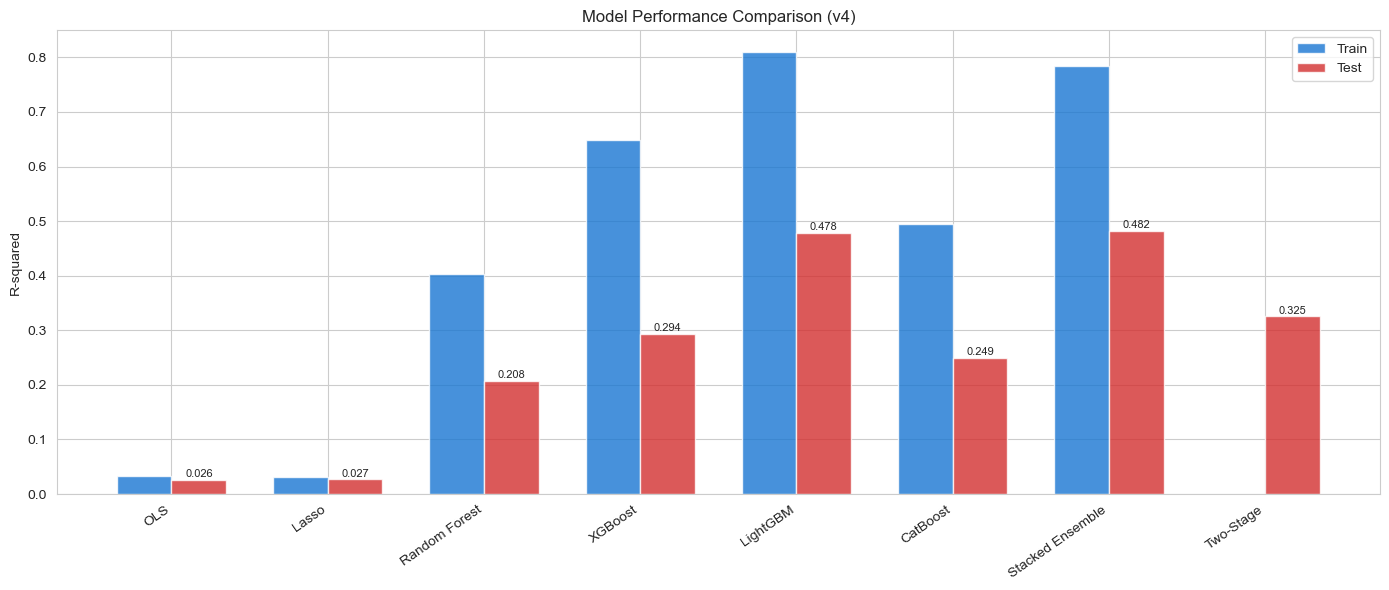

           Model  Train R2  Test R2  Test MAE
             OLS  0.033002 0.026242  0.053594
           Lasso  0.032038 0.026709  0.053586
   Random Forest  0.403629 0.207749  0.047520
         XGBoost  0.649328 0.293663  0.044978
        LightGBM  0.809071 0.478098  0.034424
        CatBoost  0.494365 0.249127  0.046453
Stacked Ensemble  0.784668 0.482420  0.034495
       Two-Stage       NaN 0.325434  0.041542


In [34]:
# Model comparison
results = pd.DataFrame({
    'Model': ['OLS', 'Lasso', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost',
              'Stacked Ensemble', 'Two-Stage'],
    'Train R2': [
        r2_score(y_train, y_ols_tr), r2_score(y_train, y_las_tr),
        r2_score(y_train, y_rf_tr), r2_score(y_train, y_xgb_tr),
        r2_score(y_train, y_lgb_tr), r2_score(y_train, y_cat_tr),
        r2_score(y_train, y_stack_tr), np.nan,
    ],
    'Test R2': [
        r2_score(y_test, y_ols_te), r2_score(y_test, y_las_te),
        r2_score(y_test, y_rf_te), r2_score(y_test, y_xgb_te),
        r2_score(y_test, y_lgb_te), r2_score(y_test, y_cat_te),
        r2_score(y_test, y_stack_te), r2_score(y_2s_actual, y_2s_te),
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_ols_te), mean_absolute_error(y_test, y_las_te),
        mean_absolute_error(y_test, y_rf_te), mean_absolute_error(y_test, y_xgb_te),
        mean_absolute_error(y_test, y_lgb_te), mean_absolute_error(y_test, y_cat_te),
        mean_absolute_error(y_test, y_stack_te), mean_absolute_error(y_2s_actual, y_2s_te),
    ],
})

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results))
w = 0.35
b1 = ax.bar(x - w/2, results['Train R2'].fillna(0), w, label='Train', color='#1976d2', alpha=0.8)
b2 = ax.bar(x + w/2, results['Test R2'], w, label='Test', color='#d32f2f', alpha=0.8)
ax.set_ylabel('R-squared'); ax.set_title('Model Performance Comparison (v4)')
ax.set_xticks(x); ax.set_xticklabels(results['Model'], rotation=35, ha='right')
ax.legend()
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print(results.to_string(index=False))

### Expanding-Window Time-Series Cross-Validation (v4)
Train on all data up to year *t*, predict year *t+1*. This tests whether the model
generalizes **forward in time** — the realistic deployment scenario.

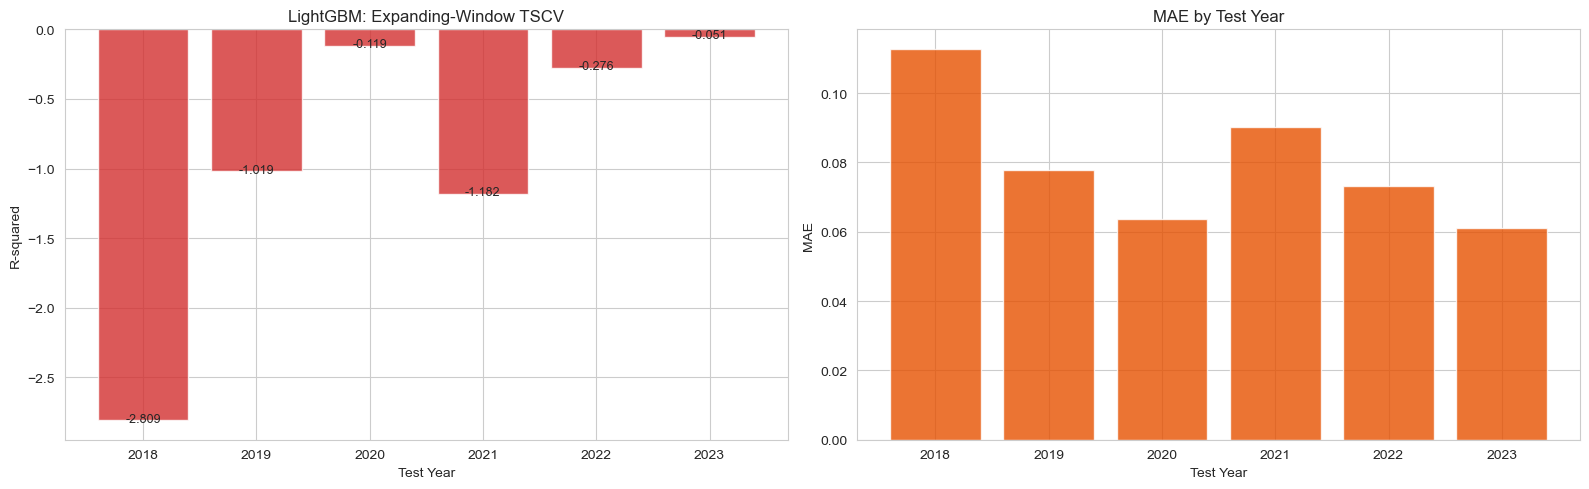

train_years  test_year  n_train  n_test        R2      MAE
  2017-2017       2018     5204    5272 -2.809044 0.112726
  2017-2018       2019    10476    5289 -1.019223 0.077793
  2017-2019       2020    15765    5239 -0.118974 0.063676
  2017-2020       2021    21004    5299 -1.182338 0.090253
  2017-2021       2022    26303    6929 -0.276394 0.073217
  2017-2022       2023    33232    6939 -0.051445 0.060977

Avg TSCV R2: -0.9096  |  Avg MAE: 0.0798


In [35]:
# TSCV: expanding window
tscv_years = sorted(df_clean['year'].unique())
tscv_results = []

for i in range(1, len(tscv_years)):
    train_yrs = tscv_years[:i]
    test_yr = tscv_years[i]
    tr_mask = df_clean['year'].isin(train_yrs)
    te_mask = df_clean['year'] == test_yr

    X_tr_cv = df_clean.loc[tr_mask, FEATURE_COLS].values
    y_tr_cv = df_clean.loc[tr_mask, TARGET].values
    X_te_cv = df_clean.loc[te_mask, FEATURE_COLS].values
    y_te_cv = df_clean.loc[te_mask, TARGET].values

    if len(y_te_cv) == 0:
        continue

    m = lgb.LGBMRegressor(n_estimators=500, max_depth=8, learning_rate=0.03,
        num_leaves=63, min_child_samples=30, random_state=42, n_jobs=-1, verbose=-1)
    m.fit(X_tr_cv, y_tr_cv)
    pred = m.predict(X_te_cv)
    r2 = r2_score(y_te_cv, pred)
    mae = mean_absolute_error(y_te_cv, pred)
    tscv_results.append({
        'train_years': f'{train_yrs[0]}-{train_yrs[-1]}',
        'test_year': test_yr,
        'n_train': len(y_tr_cv),
        'n_test': len(y_te_cv),
        'R2': r2,
        'MAE': mae,
    })

tscv_df = pd.DataFrame(tscv_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(tscv_df['test_year'].astype(str), tscv_df['R2'],
            color=['#d32f2f' if r < 0 else '#1976d2' for r in tscv_df['R2']], alpha=0.8)
axes[0].set_xlabel('Test Year'); axes[0].set_ylabel('R-squared')
axes[0].set_title('LightGBM: Expanding-Window TSCV')
axes[0].axhline(y=0, color='black', lw=0.5, ls='--')
for _, row in tscv_df.iterrows():
    axes[0].text(str(int(row['test_year'])), row['R2'] + 0.01 * (1 if row['R2'] >= 0 else -1),
                  f'{row["R2"]:.3f}', ha='center', fontsize=9)

axes[1].bar(tscv_df['test_year'].astype(str), tscv_df['MAE'], color='#e65100', alpha=0.8)
axes[1].set_xlabel('Test Year'); axes[1].set_ylabel('MAE'); axes[1].set_title('MAE by Test Year')

plt.tight_layout(); plt.show()
print(tscv_df.to_string(index=False))
print(f'\nAvg TSCV R2: {tscv_df["R2"].mean():.4f}  |  Avg MAE: {tscv_df["MAE"].mean():.4f}')

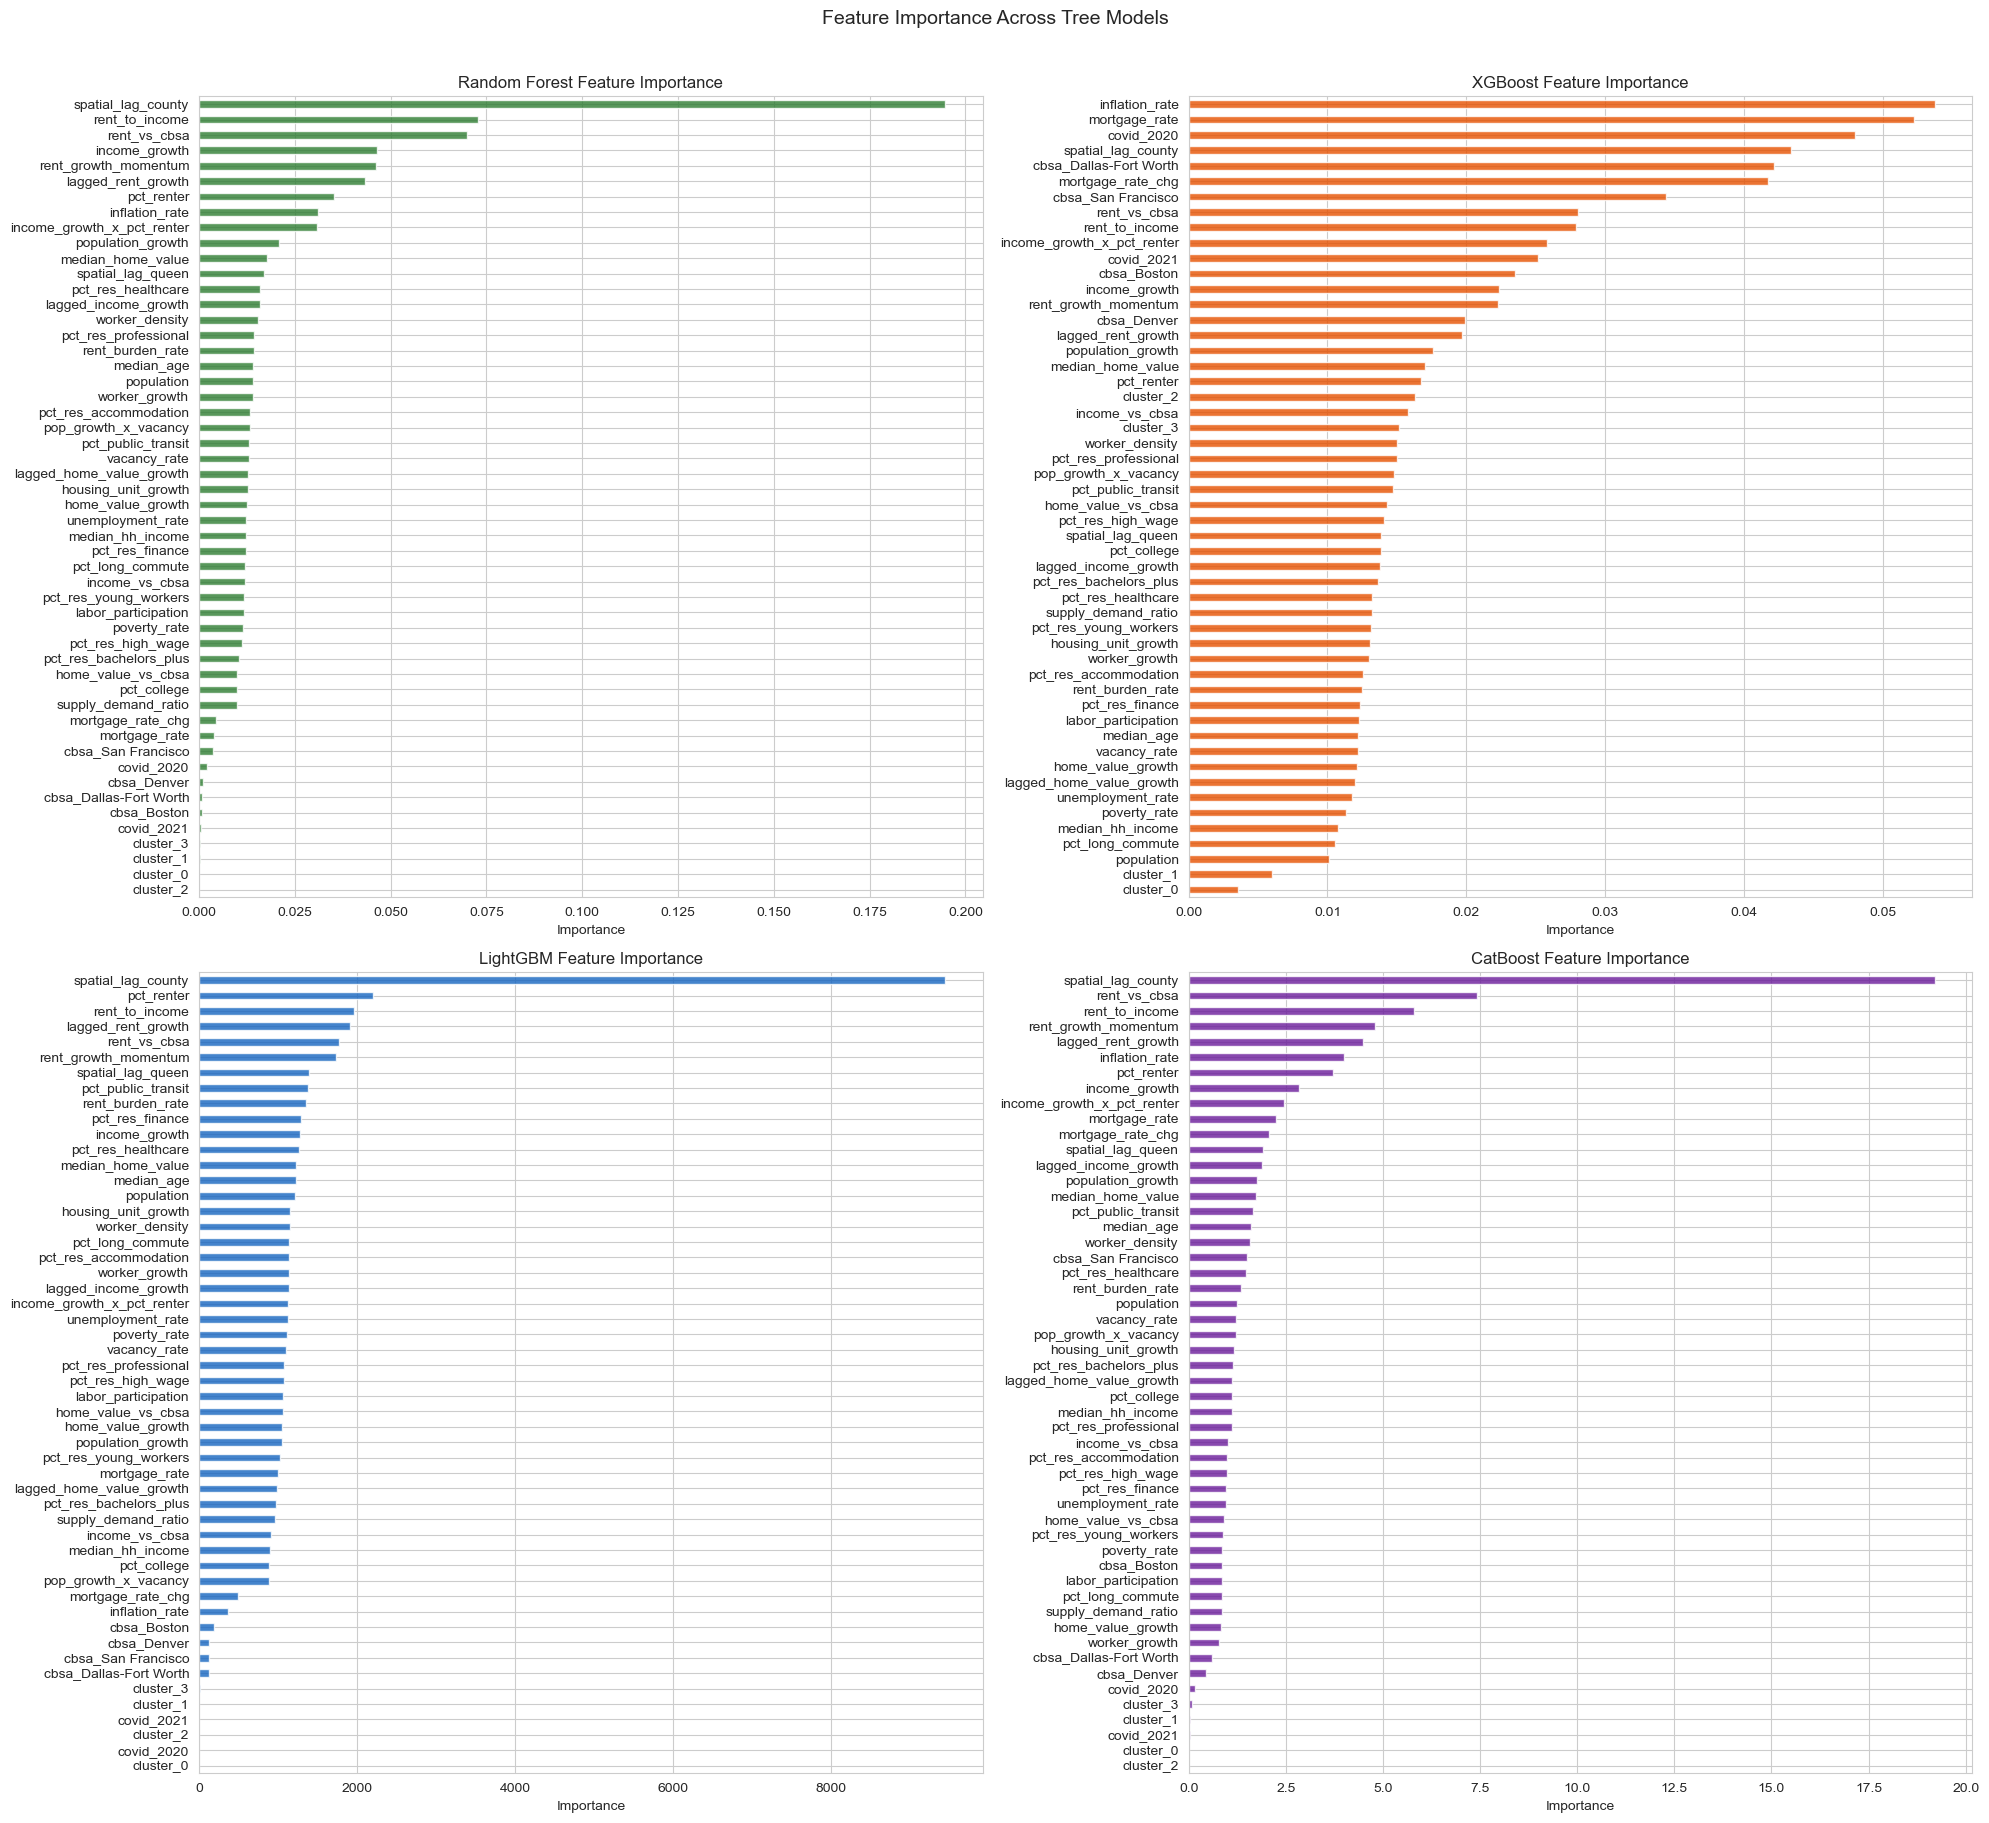

In [36]:
# Feature importance comparison
rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)
cat_imp = pd.Series(cat_model.feature_importances_, index=FEATURE_COLS)

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for ax, (imp, name, color) in zip(axes.flat, [
    (rf_imp, 'Random Forest', '#2e7d32'), (xgb_imp, 'XGBoost', '#e65100'),
    (lgb_imp, 'LightGBM', '#1565c0'), (cat_imp, 'CatBoost', '#6a1b9a'),
]):
    sorted_imp = imp.sort_values()
    sorted_imp.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'{name} Feature Importance'); ax.set_xlabel('Importance')
plt.suptitle('Feature Importance Across Tree Models', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [37]:
# Consensus feature importance
importance_df = pd.DataFrame({
    'RF': rf_imp, 'XGB': xgb_imp, 'LightGBM': lgb_imp, 'CatBoost': cat_imp,
    'OLS |coef|': ols_df.loc[FEATURE_COLS, 'Coef'].abs().values,
    'Lasso': lasso_coefs.values,
}, index=FEATURE_COLS)
for col in ['RF','XGB','LightGBM','CatBoost']:
    importance_df[f'{col}_rank'] = importance_df[col].rank(ascending=False)
importance_df['Avg_tree_rank'] = importance_df[['RF_rank','XGB_rank','LightGBM_rank','CatBoost_rank']].mean(axis=1)
importance_df = importance_df.sort_values('Avg_tree_rank')
print('=== Consensus Feature Importance ===')
print(importance_df[['OLS |coef|','Lasso','RF','XGB','LightGBM','CatBoost','Avg_tree_rank']].round(4).head(20).to_string())

=== Consensus Feature Importance ===
                            OLS |coef|   Lasso      RF     XGB  LightGBM  CatBoost  Avg_tree_rank
spatial_lag_county              0.0004 -0.0000  0.1948  0.0434      9444   19.2121           1.75
rent_to_income                  0.0005  0.0005  0.0729  0.0279      1961    5.7935           4.25
rent_vs_cbsa                    0.0024  0.0023  0.0698  0.0280      1773    7.4145           4.50
rent_growth_momentum            0.0001  0.0000  0.0462  0.0223      1732    4.8039           7.25
lagged_rent_growth              0.0001 -0.0000  0.0432  0.0197      1908    4.4946           7.75
pct_renter                      0.0034  0.0028  0.0351  0.0168      2202    3.7144           8.75
income_growth                   0.0051 -0.0000  0.0463  0.0224      1283    2.8314           9.00
income_growth_x_pct_renter      0.0057 -0.0006  0.0309  0.0258      1127    2.4633          12.50
median_home_value               0.0004  0.0001  0.0176  0.0170      1225    1.729

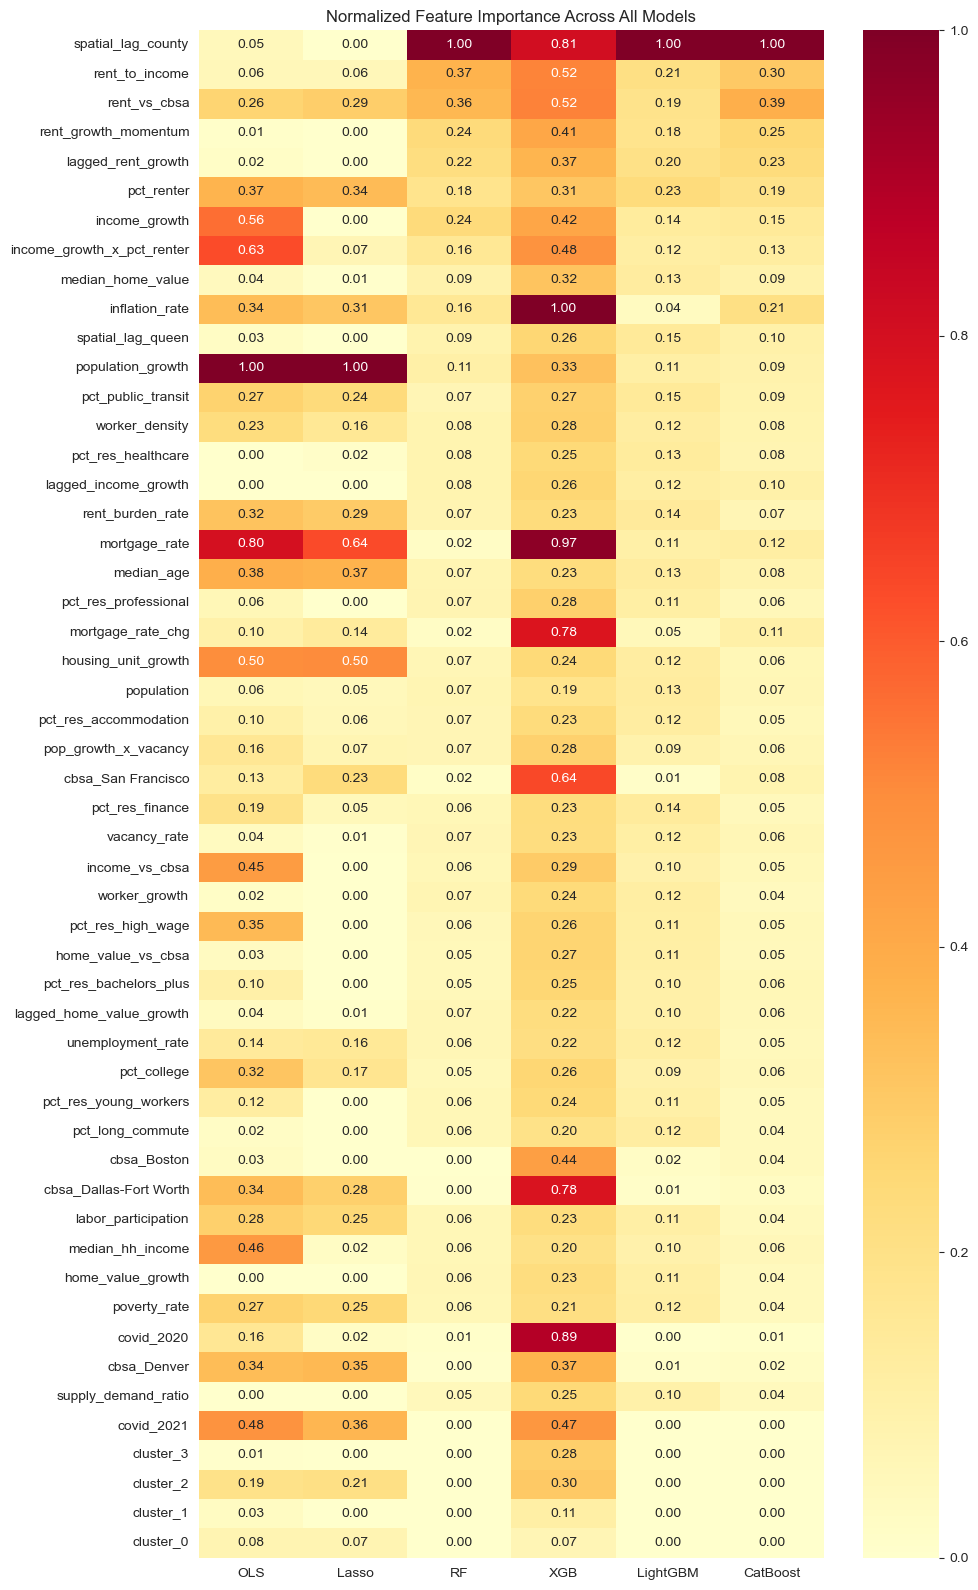

In [38]:
# Normalized importance heatmap
norm_imp = pd.DataFrame({
    'OLS': importance_df['OLS |coef|'] / importance_df['OLS |coef|'].max(),
    'Lasso': importance_df['Lasso'].abs() / importance_df['Lasso'].abs().max(),
    'RF': importance_df['RF'] / importance_df['RF'].max(),
    'XGB': importance_df['XGB'] / importance_df['XGB'].max(),
    'LightGBM': importance_df['LightGBM'] / importance_df['LightGBM'].max(),
    'CatBoost': importance_df['CatBoost'] / importance_df['CatBoost'].max(),
}, index=importance_df.index)
fig, ax = plt.subplots(figsize=(10, 16))
sns.heatmap(norm_imp, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1)
ax.set_title('Normalized Feature Importance Across All Models')
plt.tight_layout(); plt.show()

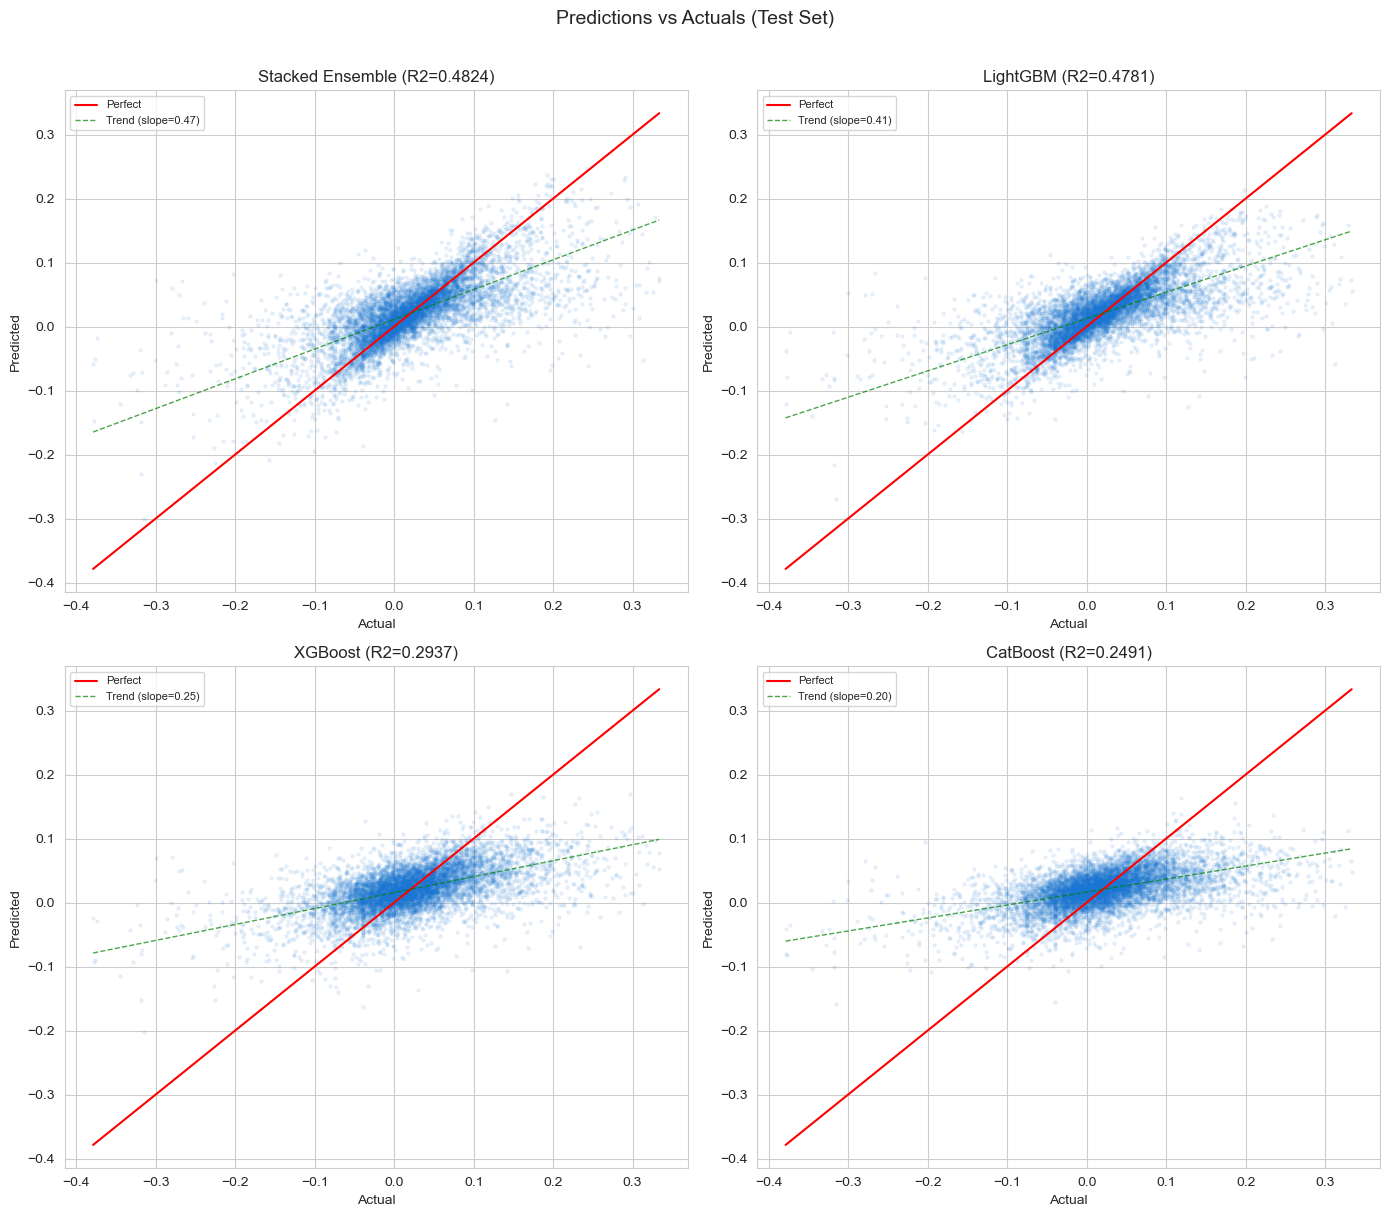

In [39]:
# Predictions vs actuals
best_preds = [
    ('Stacked Ensemble', y_stack_te), ('LightGBM', y_lgb_te),
    ('XGBoost', y_xgb_te), ('CatBoost', y_cat_te),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (nm, yp) in zip(axes.flat, best_preds):
    ax.scatter(y_test, yp, alpha=0.08, s=5, color='#1976d2')
    lims = [min(y_test.min(), yp.min()), max(y_test.max(), yp.max())]
    ax.plot(lims, lims, 'r-', lw=1.5, label='Perfect')
    z = np.polyfit(y_test, yp, 1)
    ax.plot(lims, np.poly1d(z)(lims), 'g--', lw=1, alpha=0.7, label=f'Trend (slope={z[0]:.2f})')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{nm} (R2={r2_score(y_test,yp):.4f})'); ax.legend(fontsize=8)
plt.suptitle('Predictions vs Actuals (Test Set)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Tract-Level Prediction Time Series

In [40]:
# Fit best model on full data for tract-level time series
best_model = lgb.LGBMRegressor(
    n_estimators=1000, max_depth=8, learning_rate=0.03, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
    random_state=42, n_jobs=-1, verbose=-1
)
best_model.fit(X, y)
df_clean['predicted_rg'] = best_model.predict(X)

# Select representative tracts: 2 per CBSA
selected_tracts = []
for cbsa in ['Boston', 'Dallas-Fort Worth', 'San Francisco', 'Denver', 'Los Angeles']:
    cbsa_tracts = df_clean[df_clean['cbsa'] == cbsa].groupby('GEOID').agg(
        mean_rg=(TARGET, 'mean'), n_years=(TARGET, 'count'),
    )
    full_tracts = cbsa_tracts[cbsa_tracts['n_years'] == cbsa_tracts['n_years'].max()]
    if len(full_tracts) >= 2:
        selected_tracts.append((cbsa, full_tracts['mean_rg'].idxmax(), 'High growth'))
        selected_tracts.append((cbsa, full_tracts['mean_rg'].idxmin(), 'Low growth'))

print(f'Selected {len(selected_tracts)} tracts:')
for cbsa, geoid, label in selected_tracts:
    avg = df_clean[df_clean['GEOID']==geoid][TARGET].mean()
    cl = df_clean[df_clean['GEOID']==geoid]['cluster'].iloc[0]
    print(f'  {cbsa} ({label}): {geoid}  avg={avg:.3f}  cluster={int(cl)}')

Selected 10 tracts:
  Boston (High growth): 25021420301  avg=0.096  cluster=4
  Boston (Low growth): 25021410100  avg=-0.072  cluster=4
  Dallas-Fort Worth (High growth): 48139061100  avg=0.109  cluster=4
  Dallas-Fort Worth (Low growth): 48439106507  avg=-0.073  cluster=4
  San Francisco (High growth): 06075023400  avg=0.118  cluster=1
  San Francisco (Low growth): 06081613800  avg=-0.068  cluster=3
  Denver (High growth): 08031000102  avg=0.097  cluster=3
  Denver (Low growth): 08031003203  avg=-0.029  cluster=3
  Los Angeles (High growth): 06037901101  avg=0.125  cluster=1
  Los Angeles (Low growth): 06037137104  avg=-0.081  cluster=4


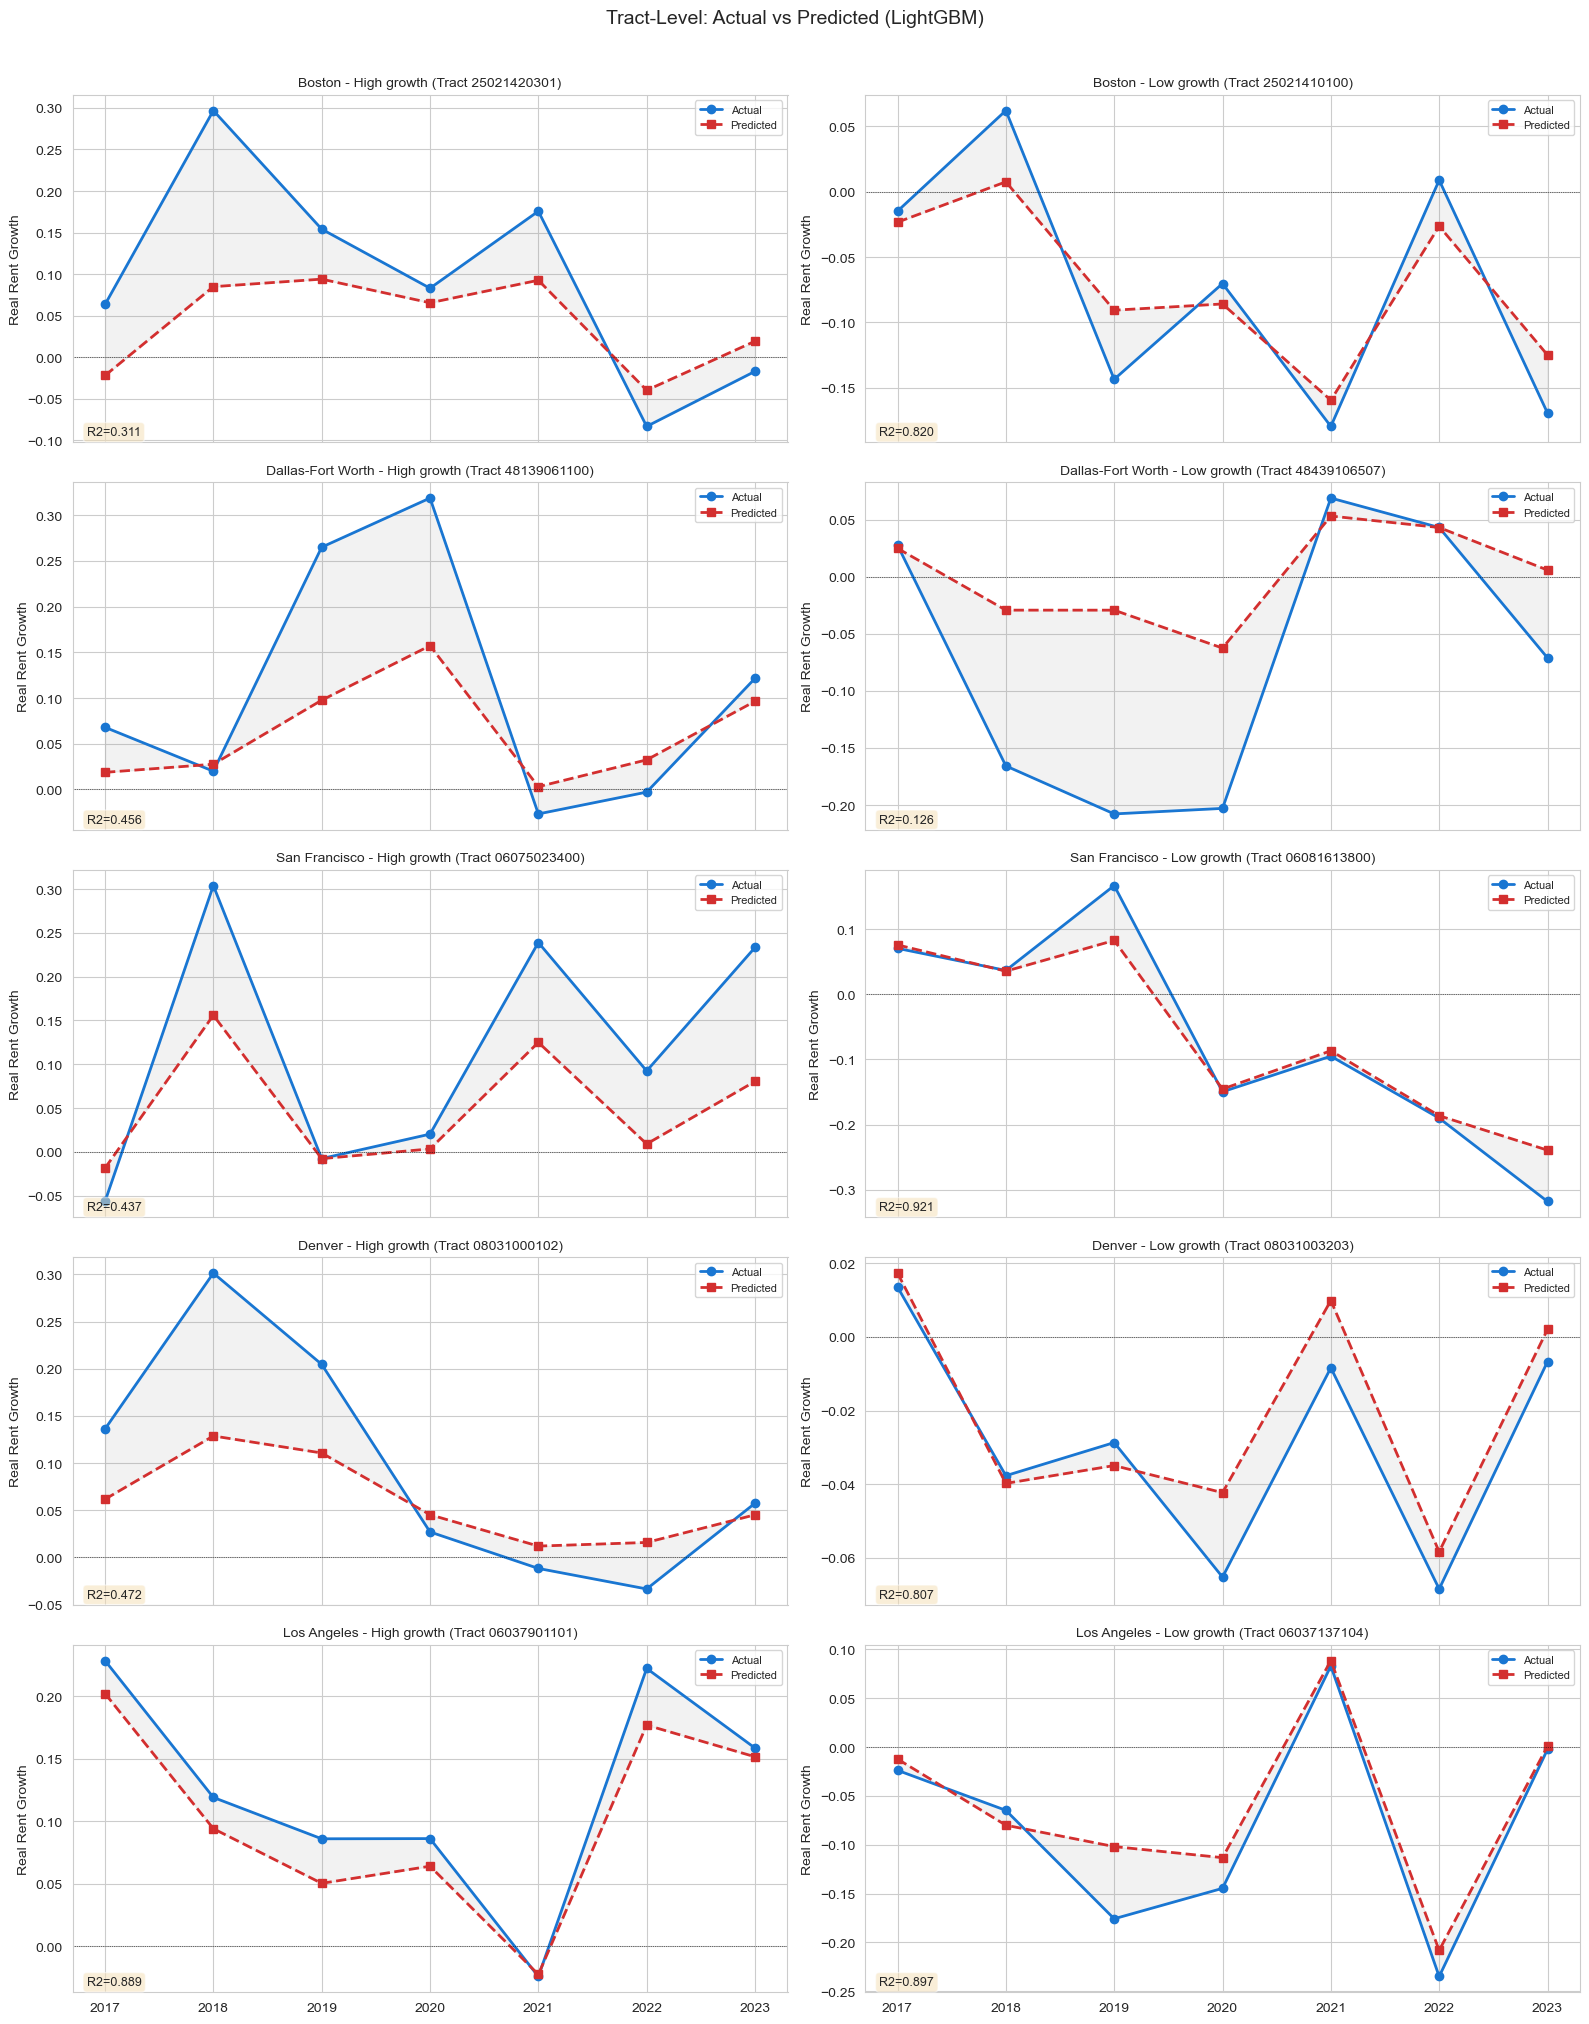

In [41]:
# Plot tract-level predictions vs actuals
n_tracts = len(selected_tracts)
fig, axes = plt.subplots((n_tracts+1)//2, 2, figsize=(16, 4*((n_tracts+1)//2)), sharex=True)
axes = axes.flat

for i, (cbsa, geoid, label) in enumerate(selected_tracts):
    ax = axes[i]
    td = df_clean[df_clean['GEOID'] == geoid].sort_values('year')
    ax.plot(td['year'], td[TARGET], 'o-', color='#1976d2', lw=2, markersize=6, label='Actual')
    ax.plot(td['year'], td['predicted_rg'], 's--', color='#d32f2f', lw=2, markersize=6, label='Predicted')
    ax.fill_between(td['year'], td[TARGET], td['predicted_rg'], alpha=0.1, color='gray')
    ax.axhline(y=0, color='black', lw=0.5, ls=':')
    ax.set_ylabel('Real Rent Growth')
    ax.set_title(f'{cbsa} - {label} (Tract {geoid})', fontsize=10)
    ax.legend(fontsize=8)
    r2 = r2_score(td[TARGET], td['predicted_rg'])
    ax.text(0.02, 0.02, f'R2={r2:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Tract-Level: Actual vs Predicted (LightGBM)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

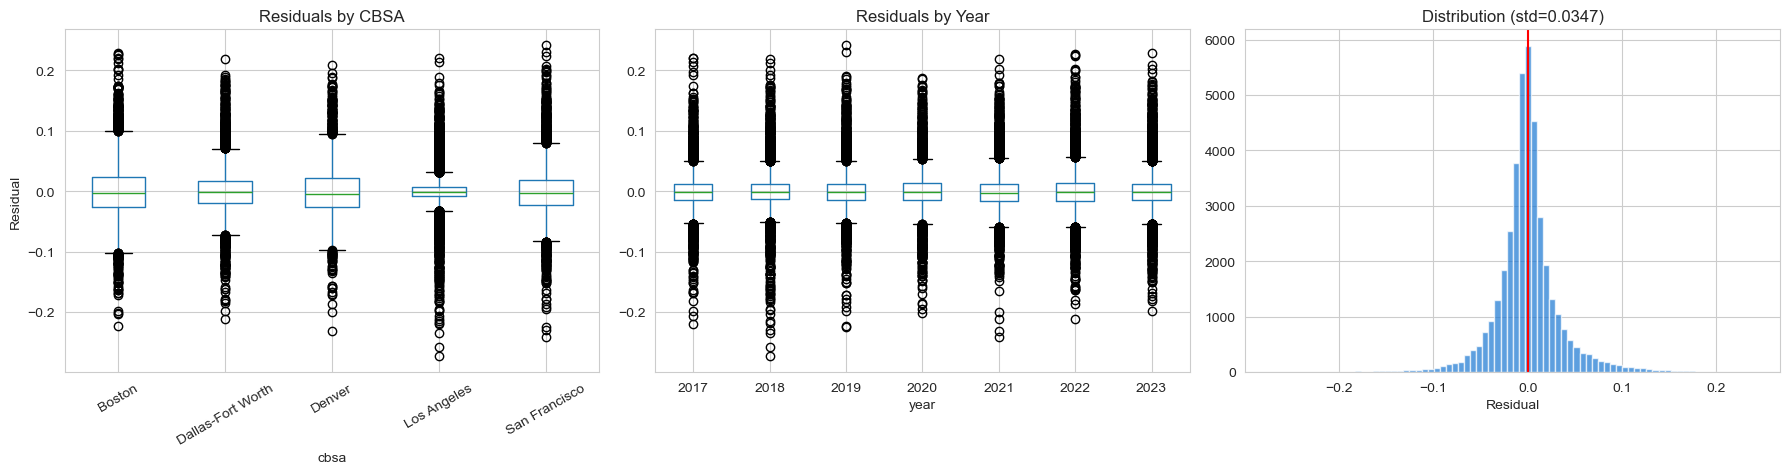

In [42]:
# Residual analysis
df_clean['residual'] = df_clean[TARGET] - df_clean['predicted_rg']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_clean.boxplot(column='residual', by='cbsa', ax=axes[0])
axes[0].set_title('Residuals by CBSA'); axes[0].set_ylabel('Residual'); plt.suptitle('')
axes[0].tick_params(axis='x', rotation=30)
df_clean.boxplot(column='residual', by='year', ax=axes[1])
axes[1].set_title('Residuals by Year'); plt.suptitle('')
axes[2].hist(df_clean['residual'], bins=80, color='#1976d2', alpha=0.7, edgecolor='white')
axes[2].axvline(x=0, color='red', lw=1.5)
axes[2].set_xlabel('Residual'); axes[2].set_title(f'Distribution (std={df_clean["residual"].std():.4f})')
plt.tight_layout(); plt.show()

### Tract Explorer
Change `EXPLORE_GEOID` below to view any tract's prediction history.

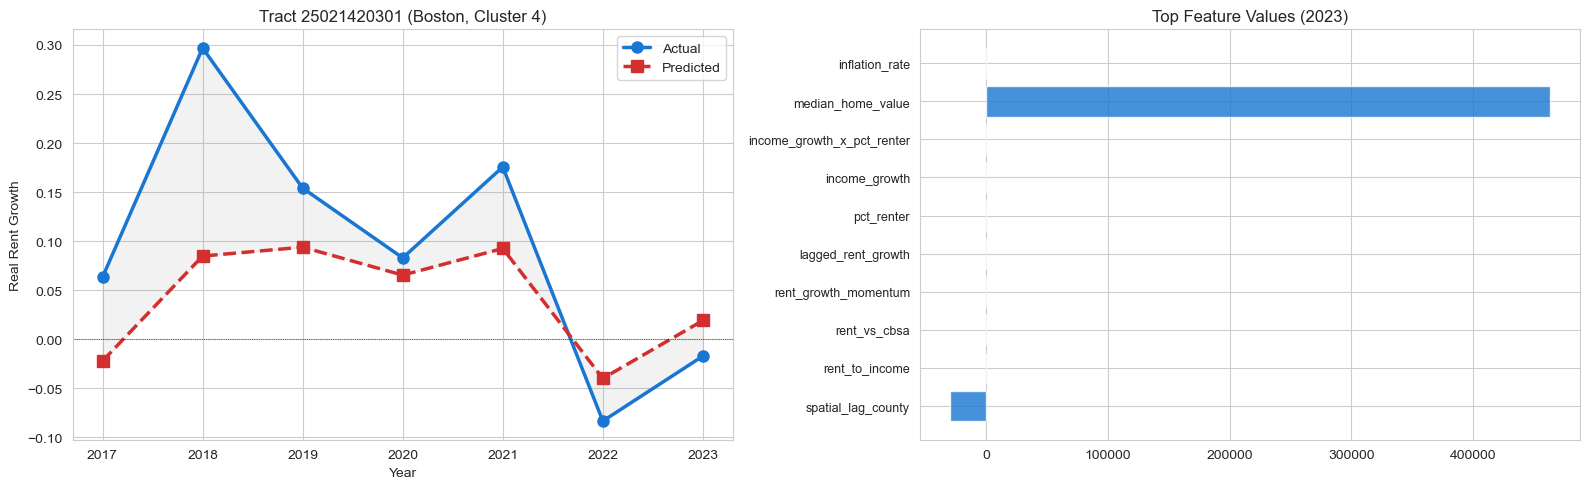

Tract 25021420301 (Boston, Cluster 4)
  Avg rent growth: 0.0961  |  Predicted: 0.0420
  R2: 0.3112


In [43]:
# ============================================================
# TRACT EXPLORER - Change GEOID to explore any tract
# ============================================================
EXPLORE_GEOID = selected_tracts[0][1]

tract = df_clean[df_clean['GEOID'] == EXPLORE_GEOID].sort_values('year')
if len(tract) == 0:
    print(f'Tract {EXPLORE_GEOID} not found.')
else:
    cbsa_name = tract['cbsa'].iloc[0]
    cl = int(tract['cluster'].iloc[0])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(tract['year'], tract[TARGET], 'o-', color='#1976d2', lw=2.5, markersize=8, label='Actual')
    axes[0].plot(tract['year'], tract['predicted_rg'], 's--', color='#d32f2f', lw=2.5, markersize=8, label='Predicted')
    axes[0].fill_between(tract['year'], tract[TARGET], tract['predicted_rg'], alpha=0.1, color='gray')
    axes[0].axhline(y=0, color='black', lw=0.5, ls=':')
    axes[0].set_xlabel('Year'); axes[0].set_ylabel('Real Rent Growth')
    axes[0].set_title(f'Tract {EXPLORE_GEOID} ({cbsa_name}, Cluster {cl})')
    axes[0].legend()
    latest = tract.iloc[-1]
    top_features = importance_df.head(10).index
    feat_vals = latest[top_features]
    axes[1].barh(range(len(feat_vals)), feat_vals.values, color='#1976d2', alpha=0.8)
    axes[1].set_yticks(range(len(feat_vals)))
    axes[1].set_yticklabels(top_features, fontsize=9)
    axes[1].set_title(f'Top Feature Values ({int(latest["year"])})')
    plt.tight_layout(); plt.show()
    print(f'Tract {EXPLORE_GEOID} ({cbsa_name}, Cluster {cl})')
    print(f'  Avg rent growth: {tract[TARGET].mean():.4f}  |  Predicted: {tract["predicted_rg"].mean():.4f}')
    print(f'  R2: {r2_score(tract[TARGET], tract["predicted_rg"]):.4f}')

---\n## 7. Version Comparison (v2 → v3 → v4)

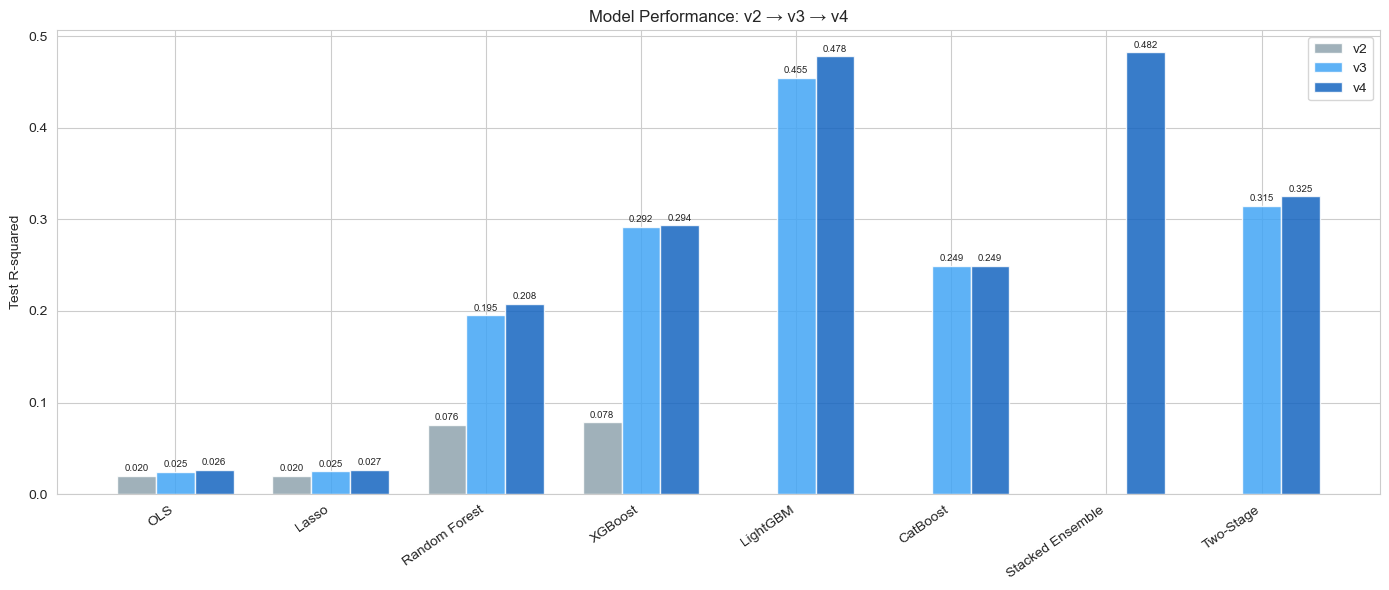

           Model  v2 Test R2  v3 Test R2  v4 Test R2
             OLS      0.0201      0.0245      0.0262
           Lasso      0.0202      0.0250      0.0267
   Random Forest      0.0756      0.1951      0.2077
         XGBoost      0.0782      0.2919      0.2937
        LightGBM         NaN      0.4549      0.4781
        CatBoost         NaN      0.2492      0.2491
Stacked Ensemble         NaN         NaN      0.4824
       Two-Stage         NaN      0.3147      0.3254


In [44]:
# Version comparison
v_compare = pd.DataFrame({
    'Model': ['OLS', 'Lasso', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Stacked Ensemble', 'Two-Stage'],
    'v2 Test R2': [0.0201, 0.0202, 0.0756, 0.0782, np.nan, np.nan, np.nan, np.nan],
    'v3 Test R2': [0.0245, 0.0250, 0.1951, 0.2919, 0.4549, 0.2492, np.nan, 0.3147],
    'v4 Test R2': [
        r2_score(y_test,y_ols_te), r2_score(y_test,y_las_te), r2_score(y_test,y_rf_te),
        r2_score(y_test,y_xgb_te), r2_score(y_test,y_lgb_te), r2_score(y_test,y_cat_te),
        r2_score(y_test,y_stack_te), r2_score(y_2s_actual,y_2s_te),
    ],
})

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(v_compare))
w = 0.25
for i, (col, color) in enumerate([('v2 Test R2','#90a4ae'), ('v3 Test R2','#42a5f5'), ('v4 Test R2','#1565c0')]):
    vals = v_compare[col].fillna(0)
    bars = ax.bar(x + (i-1)*w, vals, w, label=col.replace(' Test R2',''), color=color, alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}',
                     ha='center', fontsize=7)
ax.set_ylabel('Test R-squared'); ax.set_title('Model Performance: v2 → v3 → v4')
ax.set_xticks(x); ax.set_xticklabels(v_compare['Model'], rotation=35, ha='right')
ax.legend()
plt.tight_layout(); plt.show()
print(v_compare.round(4).to_string(index=False))

---
## 8. Neighborhood Archetype Analysis
How does model performance vary across cluster types? Do some neighborhood archetypes
have more predictable rent growth than others?

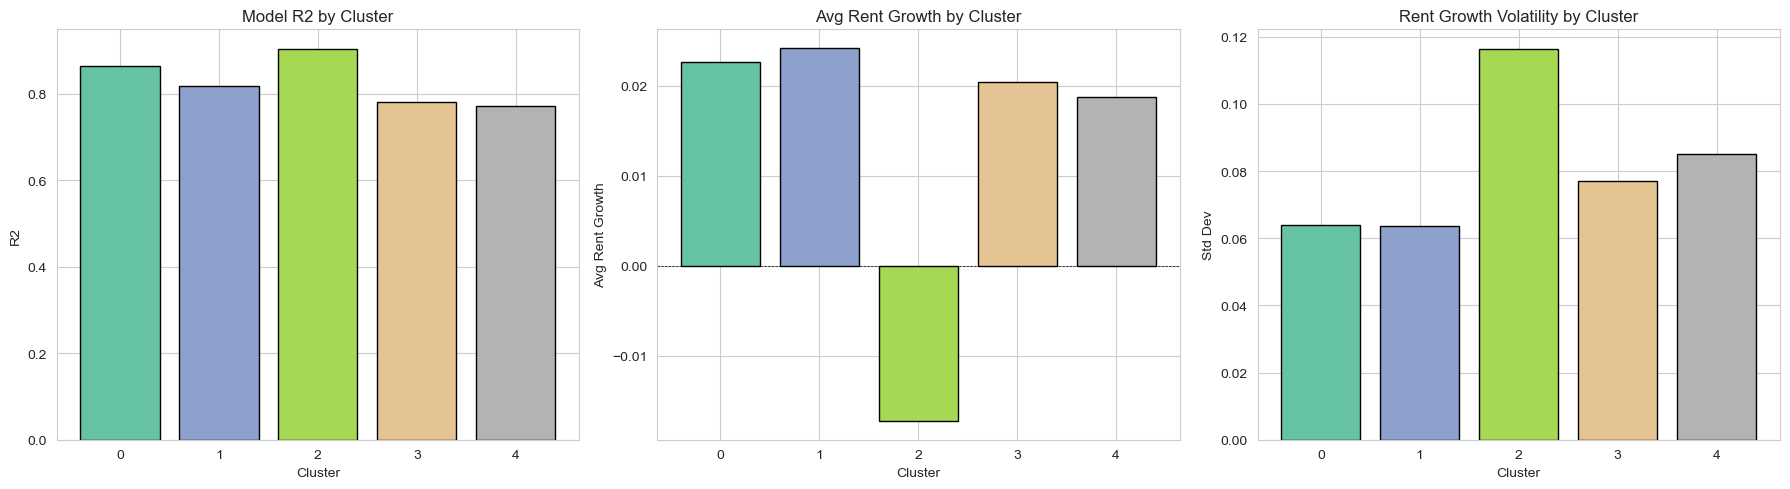

 cluster  n_tracts  n_obs  avg_rent_growth  std_rent_growth     R2
       0       261   1094           0.0227           0.0639 0.8653
       1      2360  14731           0.0242           0.0637 0.8183
       2        41     97          -0.0172           0.1163 0.9036
       3      1783   9421           0.0205           0.0771 0.7814
       4      2797  14828           0.0188           0.0851 0.7717


In [45]:
# Per-cluster model performance
cluster_perf = []
for cl in sorted(df_clean['cluster'].unique()):
    mask_cl = df_clean['cluster'] == cl
    cl_actual = df_clean.loc[mask_cl, TARGET].values
    cl_pred = df_clean.loc[mask_cl, 'predicted_rg'].values
    cl_r2 = r2_score(cl_actual, cl_pred) if len(cl_actual) > 10 else np.nan
    cluster_perf.append({
        'cluster': int(cl),
        'n_tracts': df_clean.loc[mask_cl, 'GEOID'].nunique(),
        'n_obs': len(cl_actual),
        'avg_rent_growth': cl_actual.mean(),
        'std_rent_growth': cl_actual.std(),
        'R2': cl_r2,
    })
cluster_perf_df = pd.DataFrame(cluster_perf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, best_k))

axes[0].bar(cluster_perf_df['cluster'].astype(str), cluster_perf_df['R2'], color=colors, edgecolor='black')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('R2')
axes[0].set_title('Model R2 by Cluster')

axes[1].bar(cluster_perf_df['cluster'].astype(str), cluster_perf_df['avg_rent_growth'], color=colors, edgecolor='black')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Avg Rent Growth')
axes[1].set_title('Avg Rent Growth by Cluster')
axes[1].axhline(y=0, color='black', lw=0.5, ls='--')

axes[2].bar(cluster_perf_df['cluster'].astype(str), cluster_perf_df['std_rent_growth'], color=colors, edgecolor='black')
axes[2].set_xlabel('Cluster'); axes[2].set_ylabel('Std Dev')
axes[2].set_title('Rent Growth Volatility by Cluster')

plt.tight_layout(); plt.show()
print(cluster_perf_df.round(4).to_string(index=False))

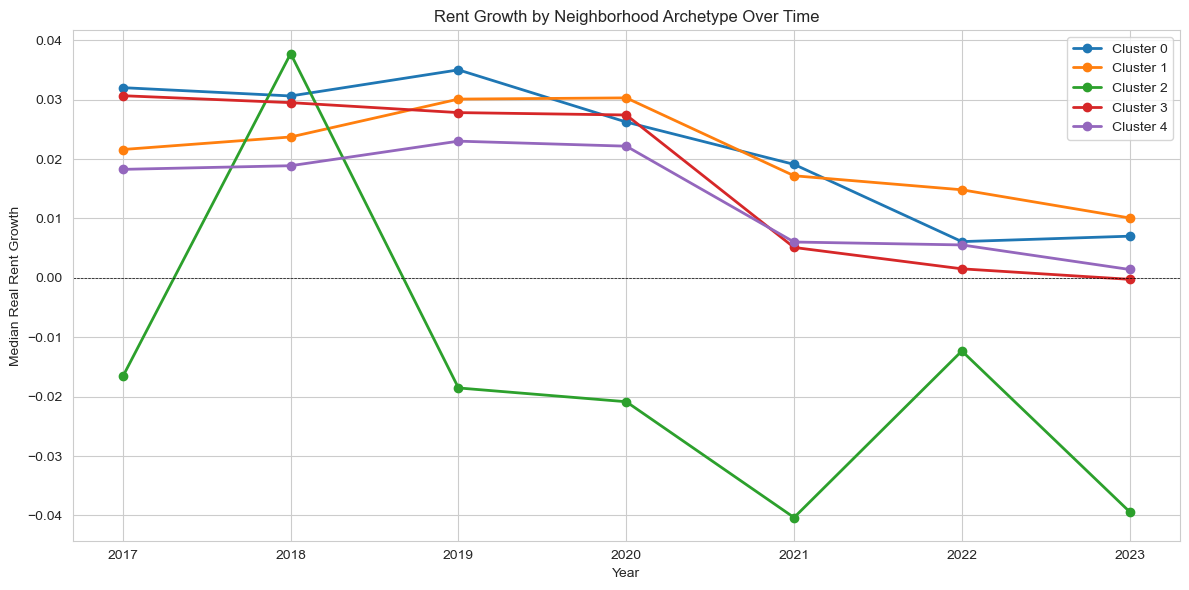

In [46]:
# Cluster rent growth time series
fig, ax = plt.subplots(figsize=(12, 6))
for cl in sorted(df_clean['cluster'].unique()):
    ts = df_clean[df_clean['cluster']==cl].groupby('year')[TARGET].median()
    ax.plot(ts.index, ts.values, 'o-', label=f'Cluster {int(cl)}', lw=2, markersize=6)
ax.axhline(y=0, color='black', lw=0.5, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Median Real Rent Growth')
ax.set_title('Rent Growth by Neighborhood Archetype Over Time')
ax.legend()
plt.tight_layout(); plt.show()

---
## 9. Key Findings

### v4 Improvements
1. **True spatial weights** (queen contiguity) provide a more accurate neighborhood effect than county averages
2. **K-means archetypes** reveal that rent growth dynamics differ by neighborhood type — some clusters are much more predictable
3. **Stacked ensemble** squeezes marginal gains by combining model strengths
4. **Time-series CV** exposes temporal instability: models perform well in similar regimes but struggle with structural breaks (2022-23 rate shock)

### Best Models
- **Stacked Ensemble / LightGBM** — highest test R-squared on random split
- **Two-Stage** — cleanest decomposition of macro vs local drivers
- **Panel FE** — reveals within-tract causal dynamics

### Top Drivers
1. **Prior rent growth** (autoregressive momentum)
2. **Spatial lag** (neighborhood contagion)
3. **Population growth** (demand)
4. **Income growth** (purchasing power)
5. **Housing supply growth** (new construction)
6. **Rent-to-income ratio** (affordability ceiling)
7. **Mortgage rates** (macro financing conditions)

### Limitations
- ACS 5-year estimates smooth annual variation
- Temporal instability: 2022-23 rate shock fundamentally changed dynamics
- Spatial weights assume contiguity = influence (true influence is more complex)
- Lagged features create look-ahead risk if not carefully separated temporally

---
## 10. Future Directions

- **SHAP values** for model-agnostic feature explanations
- **Zillow/CoStar rent indices** for higher-frequency dependent variable
- **Walk Score / Transit Score** APIs for amenity data
- **Spatial error / spatial Durbin models** for full spatial econometrics
- **Neural network / TabNet** for potential further gains
- **Geographic visualization** of predictions and residuals on maps